### LSE Data Analytics Online Career Accelerator

# Course 2: Data Analytics using Python

## 0) Assignment: Diagnostic Analysis using Python

You’ll be working with real-world data to address a problem faced by the National Health Service (NHS). The analysis will require you to utilise Python to explore the available data, create visualisations to explore and communicate trends, and extract meaningful insights to inform decision-making. This Jupyter Notebook is the starting point and it is important to document all your decisions and observations to ensure that these are available as inputs to the technical report and business presentation that will form part of your submission.

### A note for students using this template
This Jupyter Notebook is a template you can use to complete the Course 2 assignment: Diagnostic Analysis using Python. 
Keep in mind the following points: 
- Using this template as your working document is optional, it is **not required** to use this template to complete the assignment. 
- The intention of the template is to provide suggestions regarding the structure and workflow that is expected and it follows the assignment activites throughout the course.
- Refer to the guidance in the Assignment Activity pages for specific details. 
- The markup and comments in this template identify the key elements you need to complete before submitting the assignment.
- Make this notebook your own by adding comments, cells, and content to reflect your analytical journey. You can add links, screenshots, or images to support your analysis, refine or clarify the questions, and change the workflow to suit your process. Important elements include:
    - code comments
    - Markdown cells with your observations, interpretation, and notes in anticipation of the technical report and business presentation.
- All code output and visualisations should be functional and visible in the submitted Jupyter Notebook. 
- If you decide to use this template for your assignment, make a copy of the notebook and save it using the assignment naming convention: **LastName_FirstName_DA201_Assignment_Notebook.ipynb**.
- Be sure to save frequent snapshots of your Jupyter Notebook to ensure that you can recover work if required.

 > ***Markdown*** Remember to change cell types to `Markdown`. You can review [Markdown basics](https://docs.github.com/en/get-started/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax) to find out how to add formatted text, links, and images to your notebook.
 
 
 > ***Notebook state*** Remember that you will have to execute all the code in your notebook (from the start of the notebook to where you are currently working) every time you restart your Jupyter Notebook server or when working in a new session. Make sure that your notebook is in the correct state before continuing with the work for the current module.

# 

## 1) Assignment activity 1
In the first module you are encouraged to explore the data and the provided template. You should also reflect on the scenario and use case and start to document your own interpretation of the business questions and how you will go about answering them.

In [314]:
# Document your planned analytical approach.

In [315]:
# make sure to add a check for shape and 

> ***Check*** that you have adequately satisfied the expectations of the current module and that you have added code comments as well as Markdown cells documenting your analytic journey and observations to satisfy the assessment criteria.

# 

## 2) Assignment activity 2
**Basic exploration and descriptive statistics.**
- Import the three indicated data sources and perform basic exploratory analysis including obtaining descriptive statistics.
- Determine and comment on the quality, usefulness, and opportunities contained in the data sets.
- Document initial observations and findings.

Are there any comments regarding data quality or descriptive statistics worth noting for each of the data sets?
Can you comment on other features (columns) that could potentially be useful in your analysis?

### Prepare your workstation

In [316]:
# Import the necessary libraries.
import pandas as pd
import numpy as np
import sys
import matplotlib as plt
import seaborn as sns

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

In [317]:
# Import and sense-check 'actual_duration.csv' as ad.
addata = pd.read_csv('/Users/annievert/Desktop/LSE COURSE EVERYTHING/Course 2/LSE_DA201_Assignment_files- UPDATED/LSE_DA201_Assignment_files/actual_duration.csv')

# Convert to dataframe and sense check
ad = pd.DataFrame(addata)
print(ad.shape)
print(ad.columns)
ad.head()

(137793, 8)
Index(['sub_icb_location_code', 'sub_icb_location_ons_code',
       'sub_icb_location_name', 'icb_ons_code', 'region_ons_code',
       'appointment_date', 'actual_duration', 'count_of_appointments'],
      dtype='object')


,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [318]:
# Checking for null values 
ad['sub_icb_location_code'].isnull().sum()
ad['sub_icb_location_ons_code'].isnull().sum()
ad['sub_icb_location_name'].isnull().sum()
ad['icb_ons_code'].isnull().sum()
ad['region_ons_code'].isnull().sum()
ad['appointment_date'].isnull().sum()


np.int64(0)

In [319]:
# Creating a variable for missing values 
missing_variants = ['Unknown', 'Unknown / Data Quality', 'Inconsistent Mapping', 'Unmapped']

# Replacing unknown datapoints with null values 
ad_clean = ad.replace(missing_variants, np.nan)

# Determining sum of null values per column
ad_clean.isnull().sum()

sub_icb_location_code            0
sub_icb_location_ons_code        0
sub_icb_location_name            0
icb_ons_code                     0
region_ons_code                  0
appointment_date                 0
actual_duration              20161
count_of_appointments            0
dtype: int64

In [320]:
# Review metadata and descriptive statistics.
ad.describe()

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


In [321]:
# Import and sense-check 'appointments_regional.csv' as ar.
ar = pd.read_csv('/Users/annievert/Desktop/LSE COURSE EVERYTHING/Course 2/ASSIGNMENT/LSE_DA201_Assignment_files- UPDATED/LSE_DA201_Assignment_files/appointments_regional.csv')

print(ar.shape)
print(ar.columns)
ar.head()

(596821, 7)
Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [322]:
# View the DataFrame.
ar

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971
...,...,...,...,...,...,...,...
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17


In [323]:
# Replacing unknown datapoints with null values 
ar_clean = ar.replace(missing_variants, np.nan)

# Sum of null values
ar_clean.isnull().sum()

icb_ons_code                              0
appointment_month                         0
appointment_status                   201324
hcp_type                             129228
appointment_mode                      79147
time_between_book_and_appointment     29687
count_of_appointments                     0
dtype: int64

In [324]:
# Review metadata and descriptive statistics.
ar.describe

<bound method NDFrame.describe of        icb_ons_code appointment_month appointment_status hcp_type  \
0         E54000034           2020-01           Attended       GP   
1         E54000034           2020-01           Attended       GP   
2         E54000034           2020-01           Attended       GP   
3         E54000034           2020-01           Attended       GP   
4         E54000034           2020-01           Attended       GP   
...             ...               ...                ...      ...   
596816    E54000050           2022-06            Unknown  Unknown   
596817    E54000050           2022-06            Unknown  Unknown   
596818    E54000050           2022-06            Unknown  Unknown   
596819    E54000050           2022-06            Unknown  Unknown   
596820    E54000050           2022-06            Unknown  Unknown   

       appointment_mode time_between_book_and_appointment  \
0          Face-to-Face                             1 Day   
1          Face

In [325]:
# Import and sense-check 'national_categories.xlsx' as nc.
ncdata = pd.read_excel('/Users/annievert/Desktop/LSE COURSE EVERYTHING/Course 2/ASSIGNMENT/LSE_DA201_Assignment_files- UPDATED/LSE_DA201_Assignment_files/national_categories.xlsx')
nc = pd.DataFrame(ncdata)

In [326]:
# View the DataFrame.
nc

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08
...,...,...,...,...,...,...,...,...
817389,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06
817390,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06
817391,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06
817392,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06


In [327]:
# Check for missing values.
nc_clean = nc.replace(missing_variants, np.nan)

# Sum of null values
nc_clean.isnull().sum()

appointment_date              0
icb_ons_code                  0
sub_icb_location_name         0
service_setting           27419
context_type             116913
national_category        116913
count_of_appointments         0
appointment_month             0
dtype: int64

In [328]:
# Review metadata and descriptive statistics.
nc_clean.describe

<bound method NDFrame.describe of        appointment_date icb_ons_code  \
0            2021-08-02    E54000050   
1            2021-08-02    E54000050   
2            2021-08-02    E54000050   
3            2021-08-02    E54000050   
4            2021-08-02    E54000050   
...                 ...          ...   
817389       2022-06-30    E54000054   
817390       2022-06-30    E54000054   
817391       2022-06-30    E54000054   
817392       2022-06-30    E54000054   
817393       2022-06-30    E54000054   

                             sub_icb_location_name            service_setting  \
0       NHS North East and North Cumbria ICB - 00L       Primary Care Network   
1       NHS North East and North Cumbria ICB - 00L                      Other   
2       NHS North East and North Cumbria ICB - 00L           General Practice   
3       NHS North East and North Cumbria ICB - 00L           General Practice   
4       NHS North East and North Cumbria ICB - 00L           General Practice   

### Exploration suggestions:
Make sure to supplement the list with additional questions and observations that you have identified during modules 1 and 2.

**Question 1:** How many locations are there in the data set?

In [329]:
# Determine the number of locations in ad dataset.
num_locations_ad = ad_clean['sub_icb_location_name'].nunique()
print(f"There are {num_locations_ad} sub-ICB locations in the ad dataset.")

# Determine the number of locations in nc dataset.
num_locations_nc = nc_clean['sub_icb_location_name'].nunique()
print(f"There are {num_locations_nc} sub-ICB locations in the nc dataset.")


There are 106 sub-ICB locations in the ad dataset.
There are 106 sub-ICB locations in the nc dataset.


We can assume these data sets cover all sub-icb locations because according to office for natl statistics, 106 locations exist accross England 

https://www.ons.gov.uk/methodology/geography/ukgeographies/healthgeography

**Question 2:** What are the five locations with the highest number of records?

In [330]:
# Determine the top five locations based on record count.
top_locations_ad = ad_clean['sub_icb_location_name'].value_counts().head(5)
top_locations_nc = nc_clean['sub_icb_location_name'].value_counts().head(5)
print(top_locations_ad)
print(top_locations_nc)

sub_icb_location_name
NHS Norfolk and Waveney ICB - 26A                       1484
NHS Kent and Medway ICB - 91Q                           1484
NHS North West London ICB - W2U3Z                       1484
NHS Bedfordshire Luton and Milton Keynes ICB - M1J4Y    1484
NHS Greater Manchester ICB - 14L                        1484
Name: count, dtype: int64
sub_icb_location_name
NHS North West London ICB - W2U3Z              13007
NHS Kent and Medway ICB - 91Q                  12637
NHS Devon ICB - 15N                            12526
NHS Hampshire and Isle Of Wight ICB - D9Y0V    12171
NHS North East London ICB - A3A8R              11837
Name: count, dtype: int64


In [331]:
# identifying the locations with the fewest records based on both ad and nc dataset
bottom_locations_ad = ad_clean['sub_icb_location_name'].value_counts().tail(5)
bottom_locations_nc = nc_clean['sub_icb_location_name'].value_counts().tail(5)
print(bottom_locations_ad)
print(bottom_locations_nc)

sub_icb_location_name
NHS Staffordshire and Stoke-on-Trent ICB - 05D    1051
NHS South Yorkshire ICB - 03L                     1028
NHS North East and North Cumbria ICB - 00P        1025
NHS South Yorkshire ICB - 02P                     1022
NHS Cheshire and Merseyside ICB - 01F             1013
Name: count, dtype: int64
sub_icb_location_name
NHS North East and North Cumbria ICB - 00N    4210
NHS Lancashire and South Cumbria ICB - 02G    4169
NHS Cheshire and Merseyside ICB - 01V         3496
NHS Cheshire and Merseyside ICB - 01T         3242
NHS Greater Manchester ICB - 00V              2170
Name: count, dtype: int64


The locations with the highest number of records based on the NC dataframe are: 

NHS North West London ICB - W2U3Z              13007
NHS Kent and Medway ICB - 91Q                  12637
NHS Devon ICB - 15N                            12526
NHS Hampshire and Isle Of Wight ICB - D9Y0V    12171
NHS North East London ICB - A3A8R              11837

**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [332]:
# Determine the number of service settings.
service_settings = nc_clean['service_setting'].value_counts()
service_settings

service_setting
General Practice             359274
Primary Care Network         183790
Other                        138789
Extended Access Provision    108122
Name: count, dtype: int64

In [333]:
# Determine the number of context types.
context_types = nc_clean['context_type'].value_counts()
context_types

context_type
Care Related Encounter    700481
Name: count, dtype: int64

In [334]:
# Determine the number of national categories.
natl_categories = nc_clean['national_category'].value_counts()
natl_categories

national_category
General Consultation Routine                                           89329
General Consultation Acute                                             84874
Planned Clinics                                                        76429
Clinical Triage                                                        74539
Planned Clinical Procedure                                             59631
Structured Medication Review                                           44467
Service provided by organisation external to the practice              43095
Home Visit                                                             41850
Unplanned Clinical Activity                                            40415
Patient contact during Care Home Round                                 28795
Care Home Visit                                                        26644
Social Prescribing Service                                             26492
Care Home Needs Assessment & Personalised Care and Support

In [335]:
#determining total appointments in AR dataframe 
ar_clean['count_of_appointments'].sum()

np.int64(742804525)

In [336]:
# Determine the number of appointment statuses and share of total 
appt_status = ar_clean.groupby('appointment_status').sum('count_of_appointments')
appt_status['percent_of_total'] = appt_status['count_of_appointments'] / 742804525
appt_status

,count_of_appointments,percent_of_total
appointment_status,,
Attended,677755876,0.912428
DNA,30911233,0.041614


## Investigating Attendance Rates

In [337]:
# creating a variable to group locations by month and appoitnmrnt status and to filter on DNA appts
location_stats = ar_clean.groupby(['icb_ons_code','appointment_month', 'hcp_type'], as_index=False)\
['appointment_status'].agg(['count', lambda x: (x=='DNA').sum()])

# Clarifying column names 
location_stats.columns = ['icb_ons_code', 'appointment_month', 'hcp_type', 'Total_Appts', 'DNA_Appts',]

# View dataframe 
location_stats

,icb_ons_code,appointment_month,hcp_type,Total_Appts,DNA_Appts
0,E54000008,2020-01,GP,382,167
1,E54000008,2020-01,Other Practice staff,420,193
2,E54000008,2020-02,GP,383,165
3,E54000008,2020-02,Other Practice staff,423,191
4,E54000008,2020-03,GP,395,172
...,...,...,...,...,...
2515,E54000062,2022-04,Other Practice staff,59,28
2516,E54000062,2022-05,GP,63,30
2517,E54000062,2022-05,Other Practice staff,59,28
2518,E54000062,2022-06,GP,64,30


In [338]:
# Creating a column and calculating the DNA rate for all locations  
location_stats['DNA_Rate'] = (location_stats['DNA_Appts'] / location_stats['Total_Appts']) * 100

# Viewing the locations based on highest attendance rate 
location_stats.sort_values('DNA_Rate', ascending=False)

,icb_ons_code,appointment_month,hcp_type,Total_Appts,DNA_Appts,DNA_Rate
1159,E54000036,2020-10,Other Practice staff,60,31,51.666667
2073,E54000055,2021-05,Other Practice staff,76,39,51.315789
2474,E54000062,2020-08,GP,59,30,50.847458
2462,E54000062,2020-02,GP,63,32,50.793651
2519,E54000062,2022-06,Other Practice staff,62,31,50.000000
...,...,...,...,...,...,...
2126,E54000056,2021-02,GP,55,19,34.545455
1416,E54000040,2021-07,GP,47,16,34.042553
1590,E54000043,2021-04,GP,56,19,33.928571
2124,E54000056,2021-01,GP,56,19,33.928571


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, '2020-01'),
  Text(1, 0, '2020-02'),
  Text(2, 0, '2020-03'),
  Text(3, 0, '2020-04'),
  Text(4, 0, '2020-05'),
  Text(5, 0, '2020-06'),
  Text(6, 0, '2020-07'),
  Text(7, 0, '2020-08'),
  Text(8, 0, '2020-09'),
  Text(9, 0, '2020-10'),
  Text(10, 0, '2020-11'),
  Text(11, 0, '2020-12'),
  Text(12, 0, '2021-01'),
  Text(13, 0, '2021-02'),
  Text(14, 0, '2021-03'),
  Text(15, 0, '2021-04'),
  Text(16, 0, '2021-05'),
  Text(17, 0, '2021-06'),
  Text(18, 0, '2021-07'),
  Text(19, 0, '2021-08'),
  Text(20, 0, '2021-09'),
  Text(21, 0, '2021-10'),
  Text(22, 0, '2021-11'),
  Text(23, 0, '2021-12'),
  Text(24, 0, '2022-01'),
  Text(25, 0, '2022-02'),
  Text(26, 0, '2022-03'),
  Text(27, 0, '2022-04'),
  Text(28, 0, '2022-05'),
  Text(29, 0, '2022-06')])

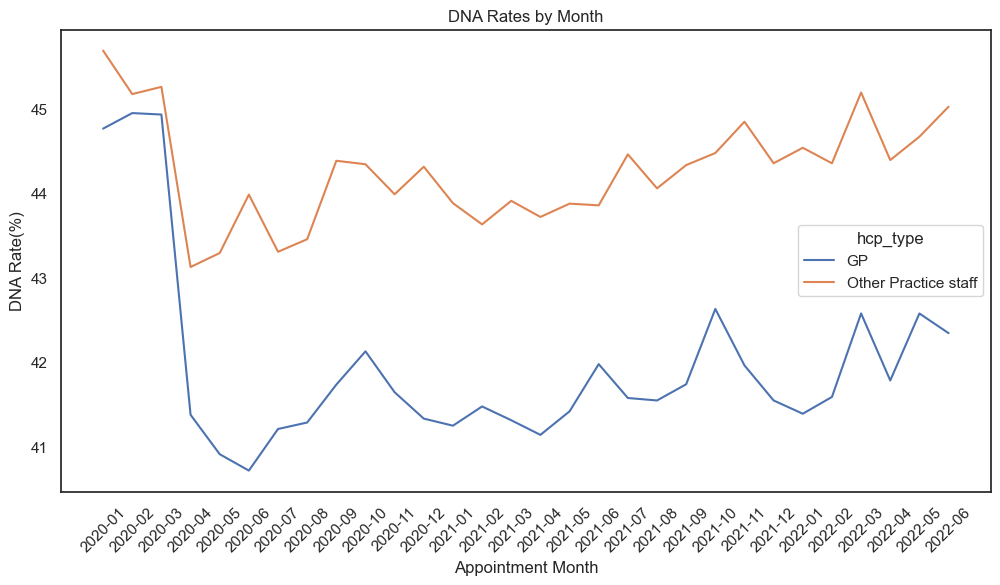

In [339]:
# Import libraries
import matplotlib.pyplot as plt

# Set figure size 
plt.figure(figsize=(12, 6))

# Create lineplot
sns.lineplot(data=location_stats, x='appointment_month', y='DNA_Rate', hue='hcp_type', ci=None)

# Rotate axis labels 
plt.xlabel('Appointment Month')
plt.ylabel('DNA Rate(%)')
plt.title('DNA Rates by Month')
plt.xticks(rotation=45)

## Finding
Other practitioners have a significantly higher DNA rate 

In [340]:
# Regional DNA analysis

# creating a variable for the 10 clinics with lowest attendance rates
DNA_top_10_worst = location_stats.sort_values('DNA_Rate', ascending=False).head(10)

#view output
DNA_top_10_worst

,icb_ons_code,appointment_month,hcp_type,Total_Appts,DNA_Appts,DNA_Rate
1159,E54000036,2020-10,Other Practice staff,60,31,51.666667
2073,E54000055,2021-05,Other Practice staff,76,39,51.315789
2474,E54000062,2020-08,GP,59,30,50.847458
2462,E54000062,2020-02,GP,63,32,50.793651
2519,E54000062,2022-06,Other Practice staff,62,31,50.000000
301,E54000018,2020-01,Other Practice staff,62,31,50.000000
2085,E54000055,2021-11,Other Practice staff,74,37,50.000000
2077,E54000055,2021-07,Other Practice staff,74,37,50.000000
1157,E54000036,2020-09,Other Practice staff,60,30,50.000000
743,E54000027,2020-12,Other Practice staff,62,31,50.000000


In [341]:
# creating a lookup on location info based on the info in the NC dataframe 
names_lookup = nc[['icb_ons_code', 'sub_icb_location_name']].drop_duplicates()

# Merge tables 
location_stats_names = location_stats.merge(names_lookup, on='icb_ons_code', how='left')

# View table
location_stats_names.head()

,icb_ons_code,appointment_month,hcp_type,Total_Appts,DNA_Appts,DNA_Rate,sub_icb_location_name
0,E54000008,2020-01,GP,382,167,43.717277,NHS Cheshire and Merseyside ICB - 01F
1,E54000008,2020-01,GP,382,167,43.717277,NHS Cheshire and Merseyside ICB - 01J
2,E54000008,2020-01,GP,382,167,43.717277,NHS Cheshire and Merseyside ICB - 01T
3,E54000008,2020-01,GP,382,167,43.717277,NHS Cheshire and Merseyside ICB - 01V
4,E54000008,2020-01,GP,382,167,43.717277,NHS Cheshire and Merseyside ICB - 01X


In [342]:
# creating variable for lowest attended appts and grouping by sub_icb
top10_lowest_DNA = location_stats_names.groupby('sub_icb_location_name',
                                                as_index=False)['DNA_Rate'].mean().sort_values(by='DNA_Rate',
                                                                                               ascending=False).head(10)
top10_lowest_DNA

,sub_icb_location_name,DNA_Rate
2,NHS Birmingham and Solihull ICB - 15E,46.849000
3,NHS Black Country ICB - D2P2L,46.512155
76,NHS North West London ICB - W2U3Z,46.367279
47,NHS Kent and Medway ICB - 91Q,45.760536
82,NHS South East London ICB - 72Q,45.447287
83,NHS South West London ICB - 36L,45.152728
19,NHS Coventry and Warwickshire ICB - B2M3M,44.252789
21,NHS Devon ICB - 15N,44.168064
78,NHS Nottingham and Nottinghamshire ICB - 02Q,44.000890
79,NHS Nottingham and Nottinghamshire ICB - 52R,44.000890


In [343]:
# Determining Locations with the best attendance rates 
top10_best_DNA = location_stats_names.groupby('sub_icb_location_name', as_index=False)['DNA_Rate'].mean().sort_values(by='DNA_Rate', ascending=True).head(10)
top10_best_DNA

,sub_icb_location_name,DNA_Rate
105,NHS West Yorkshire ICB - X2C4Y,40.569203
103,NHS West Yorkshire ICB - 15F,40.569203
102,NHS West Yorkshire ICB - 03R,40.569203
101,NHS West Yorkshire ICB - 02T,40.569203
104,NHS West Yorkshire ICB - 36J,40.569203
24,NHS Gloucestershire ICB - 11M,40.838749
41,NHS Humber and North Yorkshire ICB - 02Y,40.992847
46,NHS Humber and North Yorkshire ICB - 42D,40.992847
45,NHS Humber and North Yorkshire ICB - 03Q,40.992847
44,NHS Humber and North Yorkshire ICB - 03K,40.992847


## Key finding 
Clear outlier identified - Yorkhire has the best appointment attendance rates. It may be worth further investigation into the staffing stretgy implemented in Yorkshire. We recommend conducting a GEOJson analysis based on locational  population analysis to see if this is due to less overall demand or to determine if Yorkshire has a different staffing strategy than the rest of the country. 

## Key Finding
The best performing locations in terms of attendance rate are 90% based in Yorkshire

In [344]:
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


## Wait Time Analysis 


In [345]:
# creating a new dataframe to work off of to perform analysis
ar_wait_times = ar_clean

# Making sure all values have the same syntax 
ar_wait_times['time_between_book_and_appointment'] = ar_wait_times['time_between_book_and_appointment'].str.strip()

# Creating a dictionary to change wait times to numeric values 
wait_mapping = {
    'Same Day' : 0, 
    '1 Day' : 1, 
    '2 to 7 Days' : 4.5, 
    '8  to 14 Days' : 11,
    '15  to 21 Days': 18,
    '22  to 28 Days' : 25, 
    'More than 28 Days' : 35
}

# Add a new column to existing df and appy the wait mapping to the time between appts column 
ar_wait_times['wait_numeric'] = ar_wait_times['time_between_book_and_appointment'].map(wait_mapping)

# Calculating the amount of days that were weighted 
ar_wait_times['total_weighted_days'] = ar_wait_times['wait_numeric'] * ar_wait_times['count_of_appointments']

# View the data 
ar_wait_times

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,wait_numeric,total_weighted_days
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,1.0,8107.0
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,18.0,122238.0
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,4.5,93087.0
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,25.0,106700.0
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,11.0,131681.0
...,...,...,...,...,...,...,...,...,...
596816,E54000050,2022-06,NaN,NaN,NaN,2 to 7 Days,21,4.5,94.5
596817,E54000050,2022-06,NaN,NaN,NaN,22 to 28 Days,8,25.0,200.0
596818,E54000050,2022-06,NaN,NaN,NaN,8 to 14 Days,28,11.0,308.0
596819,E54000050,2022-06,NaN,NaN,NaN,More than 28 Days,17,35.0,595.0


In [346]:
# Aggregate based on location and practitioner type 

# Merging tables based on previous Names lookup Dataframe created with NC
summary = ar_wait_times.merge(names_lookup, on='icb_ons_code', how='left')

# Grouping data by summing up weighted values for each sub icb location 
summary = summary.groupby(['sub_icb_location_name', 'hcp_type']).agg({
                                 'total_weighted_days' : 'sum', 
                                 'count_of_appointments' : 'sum'
                                 }).reset_index()

# Calculating average wait times per location and health care type 
summary['avg_wait_days'] = summary['total_weighted_days'] / summary['count_of_appointments']

summary.head(10)

,sub_icb_location_name,hcp_type,total_weighted_days,count_of_appointments,avg_wait_days
0,NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G,GP,26411783.5,6189425,4.267243
1,NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G,Other Practice staff,59321914.5,6892111,8.607220
2,NHS Bedfordshire Luton and Milton Keynes ICB - M1J4Y,GP,23946482.5,6041970,3.963357
3,NHS Bedfordshire Luton and Milton Keynes ICB - M1J4Y,Other Practice staff,48390207.0,5771181,8.384801
4,NHS Birmingham and Solihull ICB - 15E,GP,24061444.0,9316668,2.582623
5,NHS Birmingham and Solihull ICB - 15E,Other Practice staff,47372808.0,6328769,7.485312
6,NHS Black Country ICB - D2P2L,GP,26139402.5,9630737,2.714164
7,NHS Black Country ICB - D2P2L,Other Practice staff,49873929.0,7386543,6.751999
8,NHS Bristol North Somerset and South Gloucestershire ICB - 15C,GP,22341673.5,6395793,3.493183
9,NHS Bristol North Somerset and South Gloucestershire ICB - 15C,Other Practice staff,46960330.5,5817582,8.072139


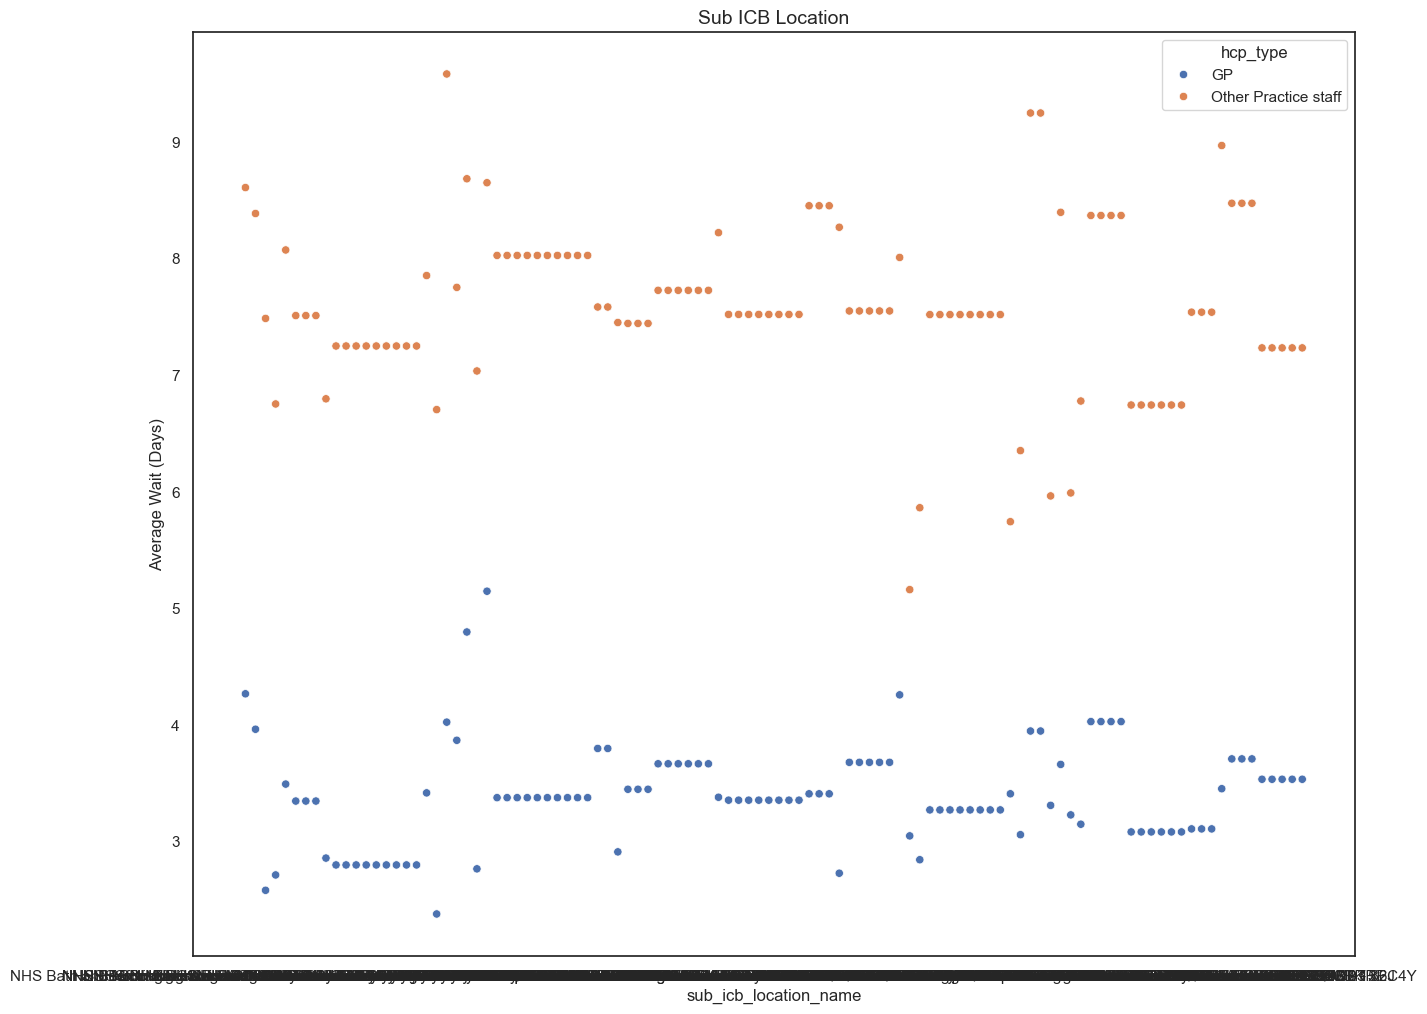

In [347]:
# visiualise distribution of wait times accross hcp type 
sns.scatterplot(data=summary, hue='hcp_type', x='sub_icb_location_name', y='avg_wait_days')

# Format the table 
plt.ylabel('Average Wait (Days)')
plt.title('Sub ICB Location', fontsize=14)
plt.show()

## Key Finding
Clear distinction between wait time and HCP type. 


Text(0, 0.5, 'Average Wait Time (Days)')

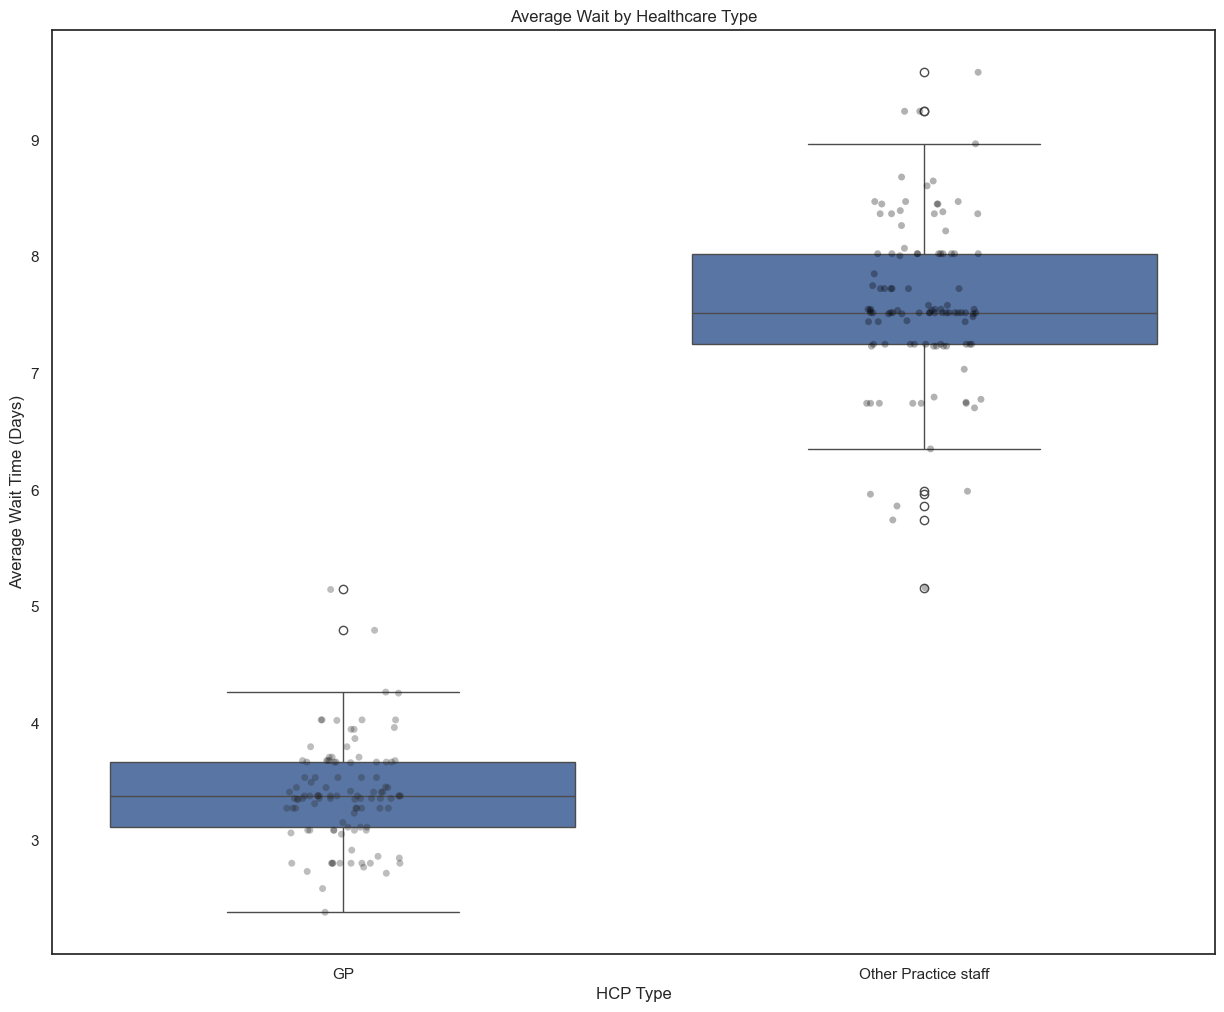

In [348]:
# Visualising data using boxplot / stripplot to see spread per category 
sns.boxplot(data=summary, x='hcp_type', y='avg_wait_days')

# Set variable and refine table 
plot_healthcare = sns.stripplot(data=summary, x='hcp_type', y='avg_wait_days', hue='hcp_type',
              color='black', alpha=0.3)
# Formatting 
plot_healthcare.set_title('Average Wait by Healthcare Type')
plot_healthcare.set_xlabel('HCP Type')
plot_healthcare.set_ylabel('Average Wait Time (Days)')

In [349]:
# Calculating medians 
medians = summary.groupby('hcp_type')['avg_wait_days'].median()
medians 

hcp_type
GP                      3.376862
Other Practice staff    7.519643
Name: avg_wait_days, dtype: float64

In [350]:
# determine GP statistics 
gp_stats = summary[summary['hcp_type'] == 'GP']
worst_gp = gp_stats.nlargest(10, 'avg_wait_days')
best_gp = gp_stats.nsmallest(10, 'avg_wait_days')

# determine Other Practitioner stats 
other_stats = summary[summary['hcp_type'] == 'Other Practice staff']
worst_other = other_stats.nlargest(10, 'avg_wait_days') 
best_other = other_stats.nsmallest(10, 'avg_wait_days')

# General best and worst 
best_overall = summary.nsmallest(10, 'avg_wait_days')
worst_overall = summary.nlargest(10, 'avg_wait_days')

# View top 5 GP's with the lowest average wait time 
best_overall

,sub_icb_location_name,hcp_type,total_weighted_days,count_of_appointments,avg_wait_days
38,NHS Coventry and Warwickshire ICB - B2M3M,GP,17039208.0,7160460,2.379625
4,NHS Birmingham and Solihull ICB - 15E,GP,24061444.0,9316668,2.582623
6,NHS Black Country ICB - D2P2L,GP,26139402.5,9630737,2.714164
118,NHS Lincolnshire ICB - 71E,GP,10250935.0,3756204,2.729068
46,NHS Frimley ICB - D4U1Y,GP,15067934.5,5446627,2.766471
18,NHS Cheshire and Merseyside ICB - 01F,GP,49620605.0,17721823,2.799972
20,NHS Cheshire and Merseyside ICB - 01J,GP,49620605.0,17721823,2.799972
22,NHS Cheshire and Merseyside ICB - 01T,GP,49620605.0,17721823,2.799972
24,NHS Cheshire and Merseyside ICB - 01V,GP,49620605.0,17721823,2.799972
26,NHS Cheshire and Merseyside ICB - 01X,GP,49620605.0,17721823,2.799972


In [351]:
# Viewing hospitals with the best wait times to compare with the worst 

# merge nc dataset with ar to include sub icb location names 
ar_merged = ar_clean.merge(names_lookup, on='icb_ons_code', how='outer')

In [352]:
# filtering based on the sub icb location names 
overall_best_location = best_overall['sub_icb_location_name'].unique()

# Filtering the merged dataframe using .isin()
overall_best_location = ar_merged[ar_merged['sub_icb_location_name'].isin(overall_best_location)]

# View the result
overall_best_location

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,wait_numeric,total_weighted_days,sub_icb_location_name
0,E54000008,2020-01,Attended,GP,Face-to-Face,1 Day,1044,1.0,1044.0,NHS Cheshire and Merseyside ICB - 01F
1,E54000008,2020-01,Attended,GP,Face-to-Face,1 Day,1044,1.0,1044.0,NHS Cheshire and Merseyside ICB - 01J
2,E54000008,2020-01,Attended,GP,Face-to-Face,1 Day,1044,1.0,1044.0,NHS Cheshire and Merseyside ICB - 01T
3,E54000008,2020-01,Attended,GP,Face-to-Face,1 Day,1044,1.0,1044.0,NHS Cheshire and Merseyside ICB - 01V
4,E54000008,2020-01,Attended,GP,Face-to-Face,1 Day,1044,1.0,1044.0,NHS Cheshire and Merseyside ICB - 01X
...,...,...,...,...,...,...,...,...,...,...
2790218,E54000062,2022-06,NaN,NaN,NaN,2 to 7 Days,58,4.5,261.0,NHS Black Country ICB - D2P2L
2790219,E54000062,2022-06,NaN,NaN,NaN,22 to 28 Days,20,25.0,500.0,NHS Black Country ICB - D2P2L
2790220,E54000062,2022-06,NaN,NaN,NaN,8 to 14 Days,67,11.0,737.0,NHS Black Country ICB - D2P2L
2790221,E54000062,2022-06,NaN,NaN,NaN,More than 28 Days,13,35.0,455.0,NHS Black Country ICB - D2P2L


This next section will explore the breakdown of best and worst healthcare providers throughout the country and look at the percentage split of GP and Other practitioner to investigate potential staffing trends and correlation with wait time efficiency 

In [353]:
# simplifying data to find percentage share breakdown 
best_summary = overall_best_location.groupby('hcp_type')['count_of_appointments'].sum().reset_index()

# creating a variable for total appts 
total_best_appts = best_summary['count_of_appointments'].sum()

# calculating the percentage split of HCP type 
best_summary['percent_of_total'] = (best_summary['count_of_appointments'] / total_best_appts) * 100
best_summary

,hcp_type,count_of_appointments,percent_of_total
0,GP,123919811,55.978713
1,Other Practice staff,97449714,44.021287


In [354]:
# same thing for worst overall 
overall_worst_location = worst_overall['sub_icb_location_name'].unique()

# Filtering the merged dataframe using .isin()
overall_worst_location = ar_merged[ar_merged['sub_icb_location_name'].isin(overall_worst_location)]

# Filtering to main data points 
worst_summary = overall_worst_location.groupby('hcp_type')['count_of_appointments'].sum().reset_index()

# creating a variable for total appts 
total_worst_appts = worst_summary['count_of_appointments'].sum()

# calculating the percentage split of HCP type 
worst_summary['percent_of_total'] = (worst_summary['count_of_appointments'] / total_worst_appts) * 100
worst_summary

,hcp_type,count_of_appointments,percent_of_total
0,GP,81352932,52.455072
1,Other Practice staff,73737756,47.544928


Text(0.5, 1.0, 'Longest Wait Locations')

<Figure size 1600x1000 with 0 Axes>

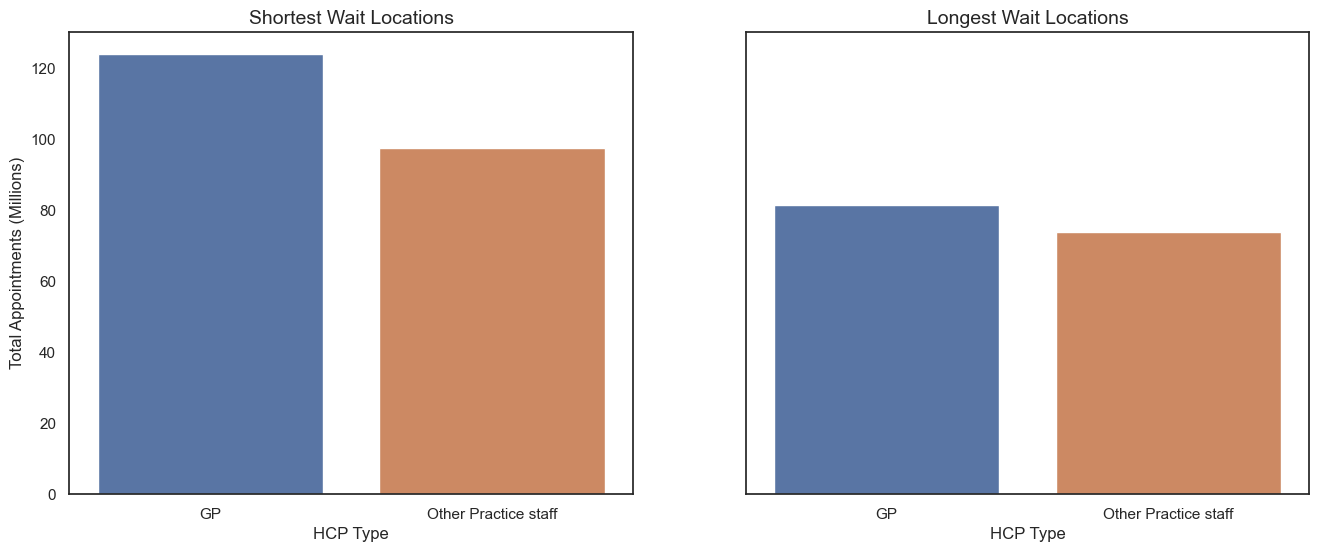

In [355]:
# making a barplot for HCP type breakdown for all the best locations 
plt.figure(figsize=(16, 10))
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.barplot(data=best_summary, x='hcp_type', 
                       y=best_summary['count_of_appointments']/1000000, hue='hcp_type', ax=axes[0])
# Formatting graph
axes[0].set_xlabel('HCP Type')
axes[0].set_ylabel('Total Appointments (Millions)')
axes[0].set_title('Shortest Wait Locations', fontsize=14)


# making a barplot for hcp type breakdpwn for the slowest locations 

sns.barplot(data=worst_summary, x='hcp_type',
            y=worst_summary['count_of_appointments']/1000000, hue='hcp_type', ax=axes[1])

# Formatting graph
axes[1].set_xlabel('HCP Type')
axes[1].set_ylabel('Total Appointments (Millions)')
axes[1].set_title('Longest Wait Locations', fontsize=14)


## Key Finding
The most efficient hospitals take a lot more appointments annd have a higher split of GP to OPs in their staff

In [356]:
# Filtering to main data points 
ar_summary = ar_clean.groupby('hcp_type')['count_of_appointments'].sum().reset_index()

# Creating a variable for total appts 
ar_total_appts = ar_summary['count_of_appointments'].sum()

# calculating the percentage split of HCP type 
ar_summary['percent_of_total'] = (ar_summary['count_of_appointments'] / ar_total_appts) * 100
ar_summary

,hcp_type,count_of_appointments,percent_of_total
0,GP,379650140,52.780451
1,Other Practice staff,339650535,47.219549


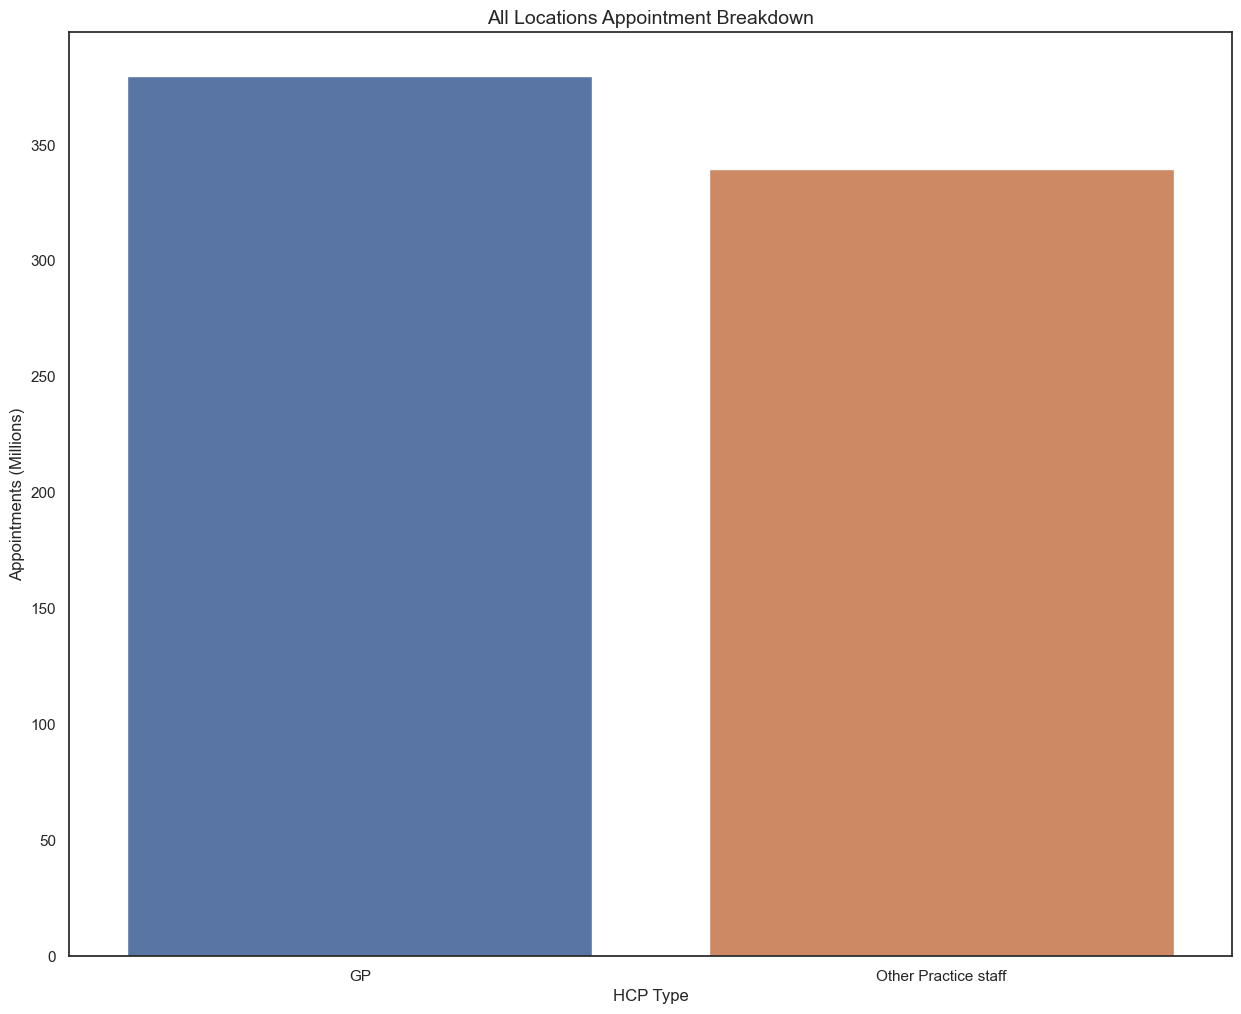

In [357]:
# Plotting overall HCP type barchart to ccompare 
sns.barplot(data=ar_summary, x='hcp_type', y=ar_summary['count_of_appointments'] / 1000000, hue='hcp_type')

# Formatting graph
plt.xlabel('HCP Type')
plt.ylabel('Appointments (Millions)')
plt.title('All Locations Appointment Breakdown', fontsize=14)
plt.show()

## Reflection & Findings
From this analysis we can see a clear trend between the locations with the lowest overall wait time vs the average and longest wait times: 

The locations with the lowest wait times had a HCP appointment split of 
- 56% GP
- 44% Other

Versus the worst overall and national average which both had the same breakdown: 
- 53% GP
- 44% Other 

> ***Check*** that you have adequately satisfied the expectations of the current module and that you have added code comments as well as Markdown cells documenting your analytic journey and observations to satisfy the assessment criteria.

# 

## 3) Assignment activity 3
Continue your exploratory data analysis by answering the specific questions posed by the NHS as well as additional trends identified during data exploration. You can start by looking at the date range and the change in behaviour over time for the available data sources.

### Continue to explore the data and search for answers to more specific questions posed by the NHS.

**Question 1:** Between what dates were appointments scheduled? 

In [358]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
ad['appointment_date'].head(5)

0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object

In [359]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.
nc['appointment_date'].head(5)

0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]

In [360]:
# Change the date format of ad['appointment_date'].
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'])

# View the DataFrame.
ad

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730
...,...,...,...,...,...,...,...,...
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,31-60 Minutes,430
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,21-30 Minutes,751
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,16-20 Minutes,921
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,11-15 Minutes,1439


In [361]:
# Change the format of ar['appointment_date'] to datetime.
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'])
ar
# View the DataFrame.
ar

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01-01,Attended,GP,Face-to-Face,8 to 14 Days,11971
...,...,...,...,...,...,...,...
596816,E54000050,2022-06-01,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06-01,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06-01,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06-01,Unknown,Unknown,Unknown,More than 28 Days,17


In [362]:
# Determine the minimum and maximum dates in the ad DataFrame.
# Use appropriate docstrings.
print("First appointment date:", ad['appointment_date'].min())
print("Latest appointment date:", ad['appointment_date'].max())

First appointment date: 2021-12-01 00:00:00
Latest appointment date: 2022-06-30 00:00:00


In [363]:
# Determine the minimum and maximum dates in the nc DataFrame.
# Use appropriate docstrings.
print("First appointment date:", nc['appointment_date'].min())
print("Latest appointment date:", nc['appointment_date'].max())

First appointment date: 2021-08-01 00:00:00
Latest appointment date: 2022-06-30 00:00:00


**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [364]:
# For each of these service settings, determine the number of records available for the period and the location. 

# creating a variable representing the filtered timeframe and location  
nw_london = nc[(nc['sub_icb_location_name'].str.contains('North West London', na=False)) &
(nc['appointment_date'] > '2022-01-1') & 
(nc['appointment_date'] < '2022-06-1')]

#creating a user defined function to implement value counts based on a specific category
def cat_cnt(df1):
    print(df1.value_counts())

# Defining variables to input into the fuction 
df = nw_london['service_setting'].astype('category')

# View the output.
cat_cnt(df)

service_setting
General Practice             2080
Other                        1307
Primary Care Network         1261
Extended Access Provision    1076
Unmapped                      150
Name: count, dtype: int64


**Question 3:** Which month had the highest number of appointments?

In [365]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.

aptmonth = nc.groupby('appointment_month')['count_of_appointments'].sum().sort_values(ascending=False)
aptmonth

# Print month with highest number of appointments
print(f"Month: {aptmonth.index[0]} had the highest number of appointments: {aptmonth.max()}")
print(aptmonth)

Month: 2021-11 had the highest number of appointments: 30405070
appointment_month
2021-11    30405070
2021-10    30303834
2022-03    29595038
2021-09    28522501
2022-05    27495508
2022-06    25828078
2022-01    25635474
2022-02    25355260
2021-12    25140776
2022-04    23913060
2021-08    23852171
Name: count_of_appointments, dtype: int64


**Question 4:** What was the total number of records per month?

In [366]:
# Total number of records per month.
nc['appointment_month'].value_counts()

appointment_month
2022-03    82822
2021-11    77652
2022-05    77425
2021-09    74922
2022-06    74168
2021-10    74078
2021-12    72651
2022-01    71896
2022-02    71769
2022-04    70012
2021-08    69999
Name: count, dtype: int64

In [367]:
nc.groupby('appointment_month')['count_of_appointments'].sum()

appointment_month
2021-08    23852171
2021-09    28522501
2021-10    30303834
2021-11    30405070
2021-12    25140776
2022-01    25635474
2022-02    25355260
2022-03    29595038
2022-04    23913060
2022-05    27495508
2022-06    25828078
Name: count_of_appointments, dtype: int64

## Reflection
The number of records and number of appointments have very different data. It seems logical to group by count of appointments because there are multiple appointments within each record. Moving forward, the count of appointments will be used insead of record count

# 

## 4) Assignment activity 4
Use visual techniques to explore and communicate patterns in the data. Note that you will likely revisit this section when preparing the final visualisations to be used in your technical report and business presentation. Make sure to document your thoughts and observations as they relate to various potential stakeholders.

The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

### Create visualisations and identify possible monthly and seasonal trends in the data.

In [368]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

### Objective 1
Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [369]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['appointment_month'] = nc['appointment_month'].astype(str)

In [370]:
# Aggregate on a monthly level and determine the sum of records per month.
nc_appt_month = nc.groupby('appointment_month')['count_of_appointments'].sum()

# Convert to a DataFrame for plotting
nc_appt_month_df = nc_appt_month.reset_index()

nc_appt_month_df = nc_appt_month_df.rename(columns={'index': 'Month'}).sort_values('appointment_month')
nc_appt_month_df

,appointment_month,count_of_appointments
0,2021-08,23852171
1,2021-09,28522501
2,2021-10,30303834
3,2021-11,30405070
4,2021-12,25140776
5,2022-01,25635474
6,2022-02,25355260
7,2022-03,29595038
8,2022-04,23913060
9,2022-05,27495508


Text(0.5, 1.0, 'Total Appointments per Month')

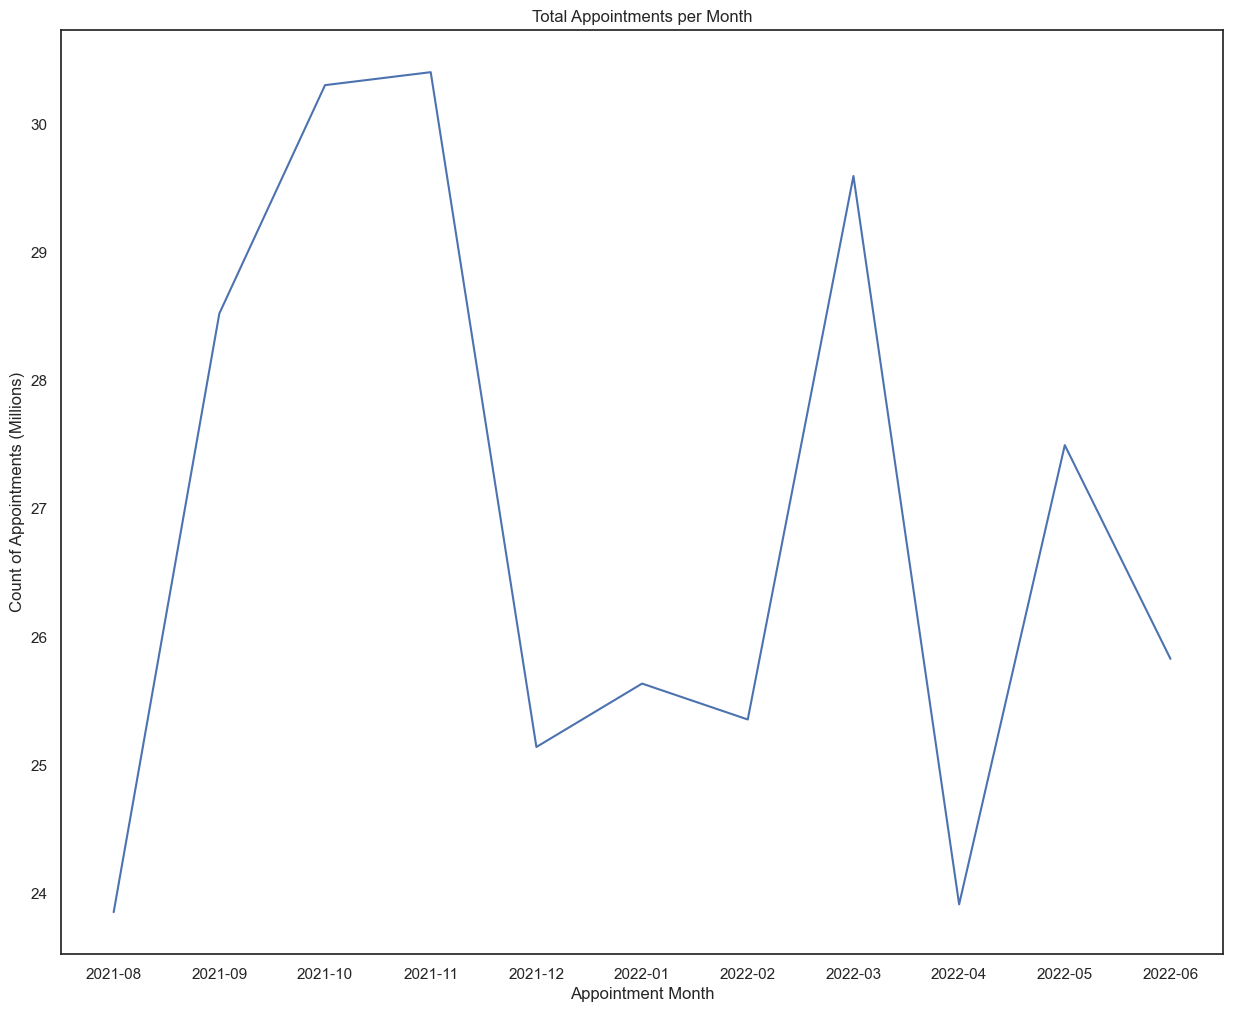

In [371]:
#Visualising data through lineplot
sns.lineplot(data=nc_appt_month_df, x='appointment_month', y= nc_appt_month_df['count_of_appointments'] / 1000000)

# Formatting Graph
plt.xlabel("Appointment Month")
plt.ylabel("Count of Appointments (Millions)")
plt.title("Total Appointments per Month")

**Service settings:**

<Axes: xlabel='appointment_month', ylabel='count_of_appointments'>

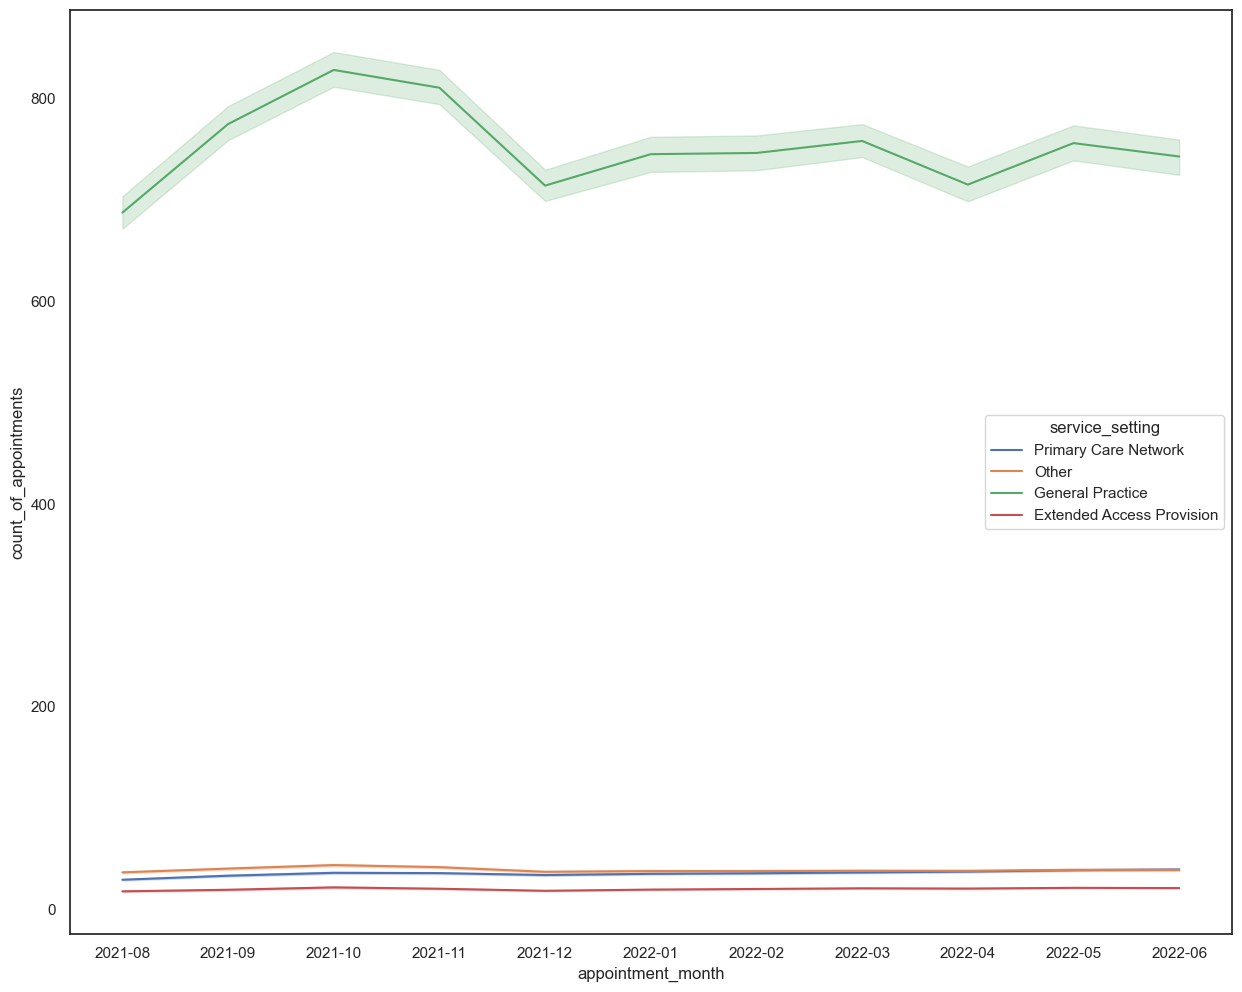

In [372]:
# Plot the appointments over the available date range, and review the service settings for months.
# Create a lineplot.
sns.lineplot(data=nc_clean, x='appointment_month', y='count_of_appointments', hue='service_setting')

## Key Finding
General Practice takes up a large majority of service setting share

**Context types:**

<Axes: xlabel='appointment_month', ylabel='count_of_appointments'>

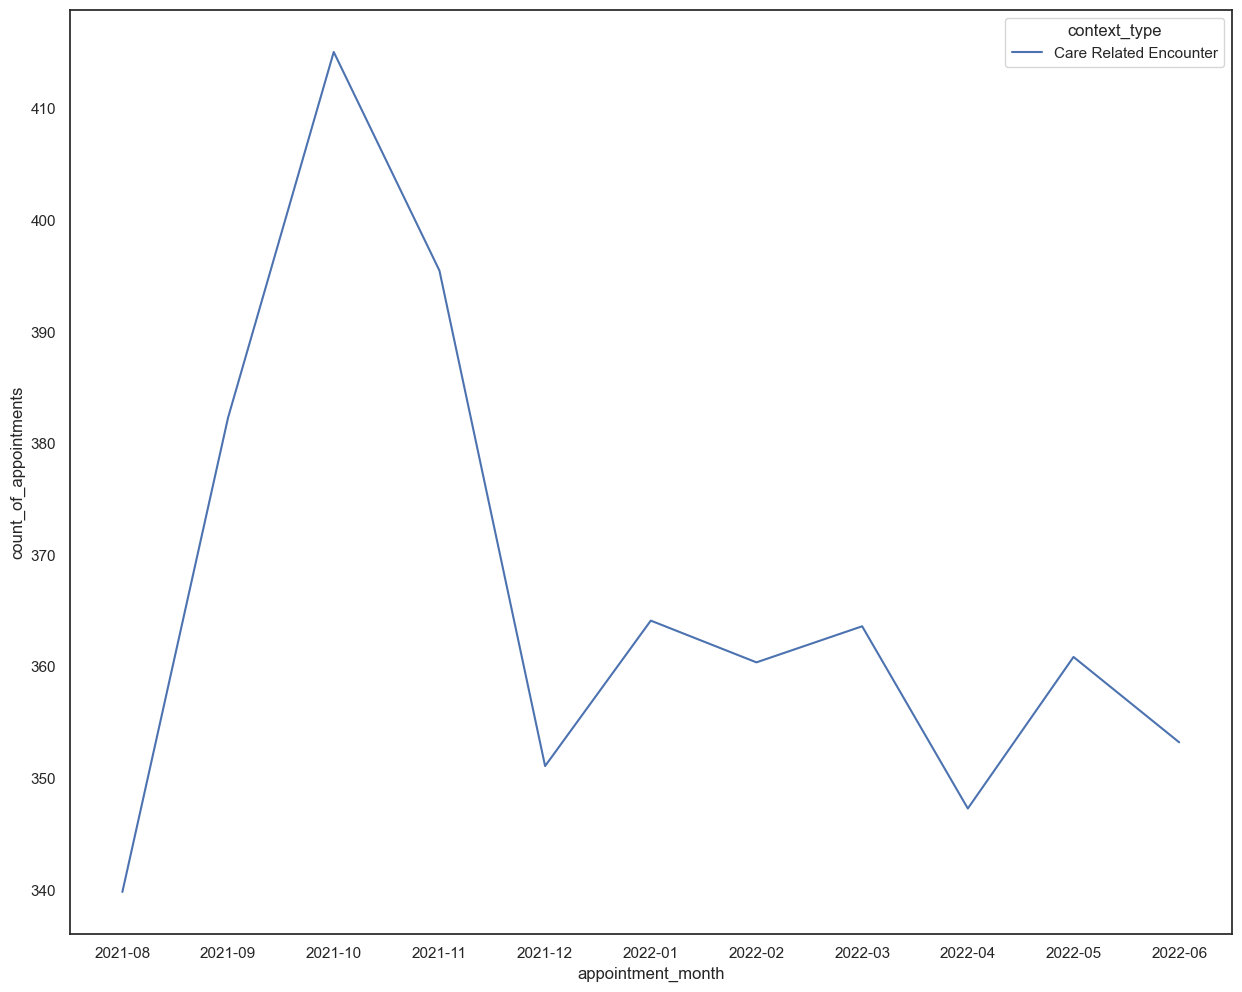

In [373]:
# Plot the appointments over the available date range, and review the context types for months.
# Create a lineplot.
sns.lineplot(data=nc_clean, x='appointment_month', y='count_of_appointments', hue='context_type', ci=None)

**National categories:**

Text(0, 0.5, 'Appointments')

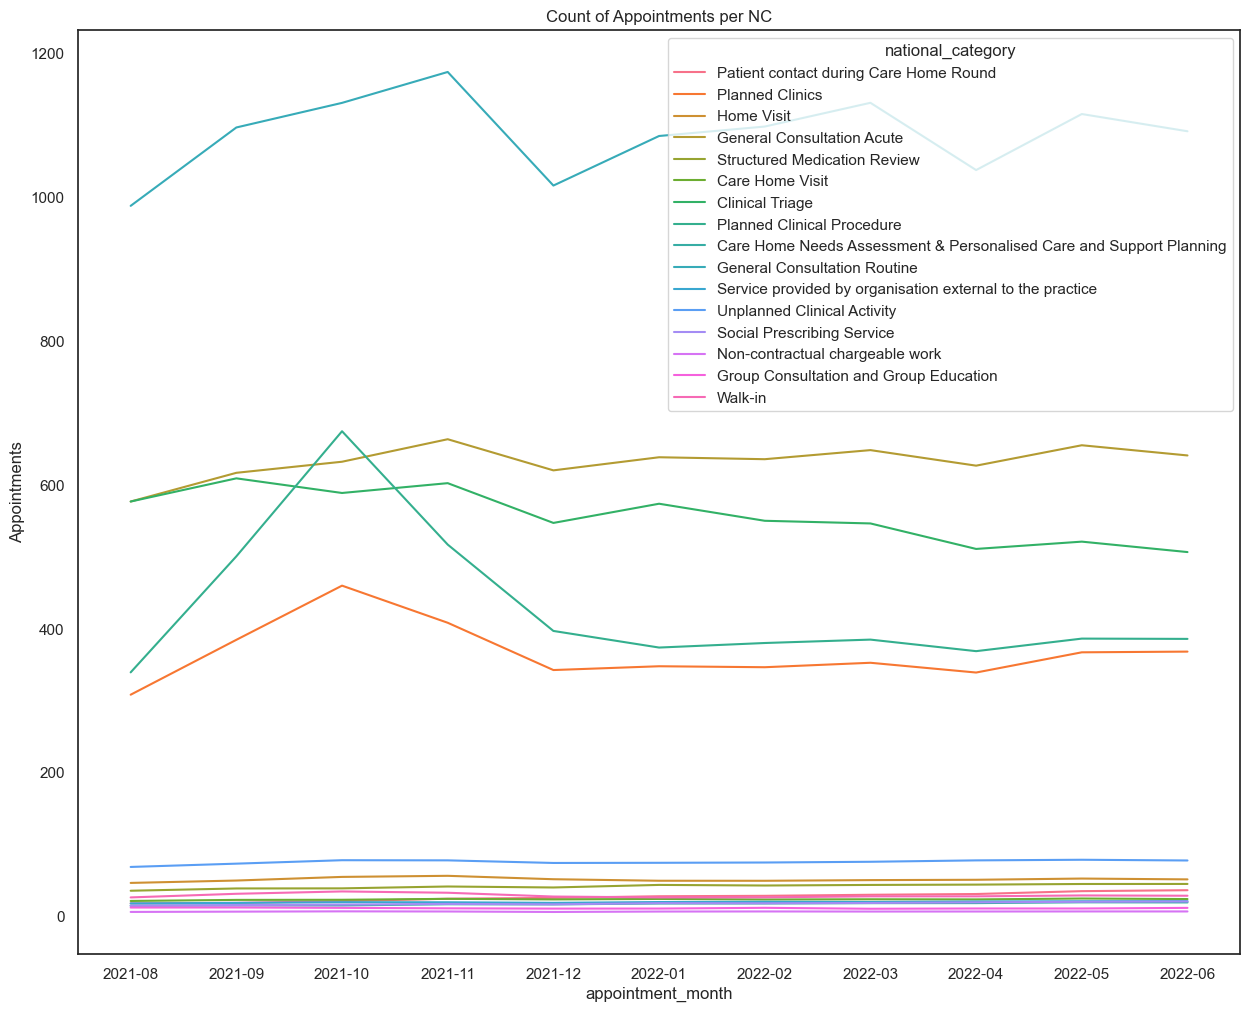

In [374]:
# Plot the appointments over the available date range, and review the national categories for months.
# Create a lineplot.
sns.lineplot(data=nc_clean, x='appointment_month', y='count_of_appointments', hue='national_category', ci=None)
plt.title('Count of Appointments per NC')
plt.ylabel('Appointments')

### Objective 2
Create four visualisations indicating the number of appointments for service setting per season.

**Summer:**


Create four visualisations (one per season) to indicate the number of appointments for service setting per season.

The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022),and spring (March to May 2022).
Aggregate the appointments per month, and determine the sum of the records per season (specified month). Create a new DataFrame (e.g. nc_ss_day). Use the groupby() function to group the date of appointment, monthly appointments, and service settings for the nc DataFrame. Calculate the total number of appointments (sum). (Hint: Remember to reset the index.) 
View the new DataFrame.
Create a lineplot with seaborn: 
Specify the x and y variables.
Specify the hue and data. (Hint: Remember to filter the data and specify the month (e.g. =='2021-08').)
Set ci=None. (Note: When creating a lineplot using Seaborn version 0.12.0 onwards, the ci parameter has been deprecated. errorbar=None should be used instead.)
Repeat Step b to visualise all the seasons.

In [375]:
# Create a separate data set that can be used in future weeks. 
nc_ss_day = nc.groupby(['appointment_date', 'appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()
# View the output.
nc_ss_day

,appointment_date,appointment_month,service_setting,count_of_appointments
0,2021-08-01,2021-08,Extended Access Provision,438
1,2021-08-01,2021-08,General Practice,3411
2,2021-08-01,2021-08,Other,401
3,2021-08-01,2021-08,Primary Care Network,323
4,2021-08-01,2021-08,Unmapped,1054
...,...,...,...,...
1665,2022-06-30,2022-06,Extended Access Provision,9163
1666,2022-06-30,2022-06,General Practice,1124374
1667,2022-06-30,2022-06,Other,23115
1668,2022-06-30,2022-06,Primary Care Network,34774


In [376]:
# Filtering out the unmapped data 
nc_ss_day = nc_ss_day[nc_ss_day['service_setting'] != 'Unmapped'] 

# Creating seasonal filters
summer = nc_ss_day[nc_ss_day['appointment_month'].isin(['2021-06', '2021-07', '2021-08'])]
autumn = nc_ss_day[nc_ss_day['appointment_month'].isin(['2021-09', '2021-10', '2021-11'])]
winter = nc_ss_day[nc_ss_day['appointment_month'].isin(['2021-12', '2022-01', '2022-02'])]
spring = nc_ss_day[nc_ss_day['appointment_month'].isin(['2022-03', '2022-04', '2022-05'])]

<Axes: xlabel='appointment_date', ylabel='count_of_appointments'>

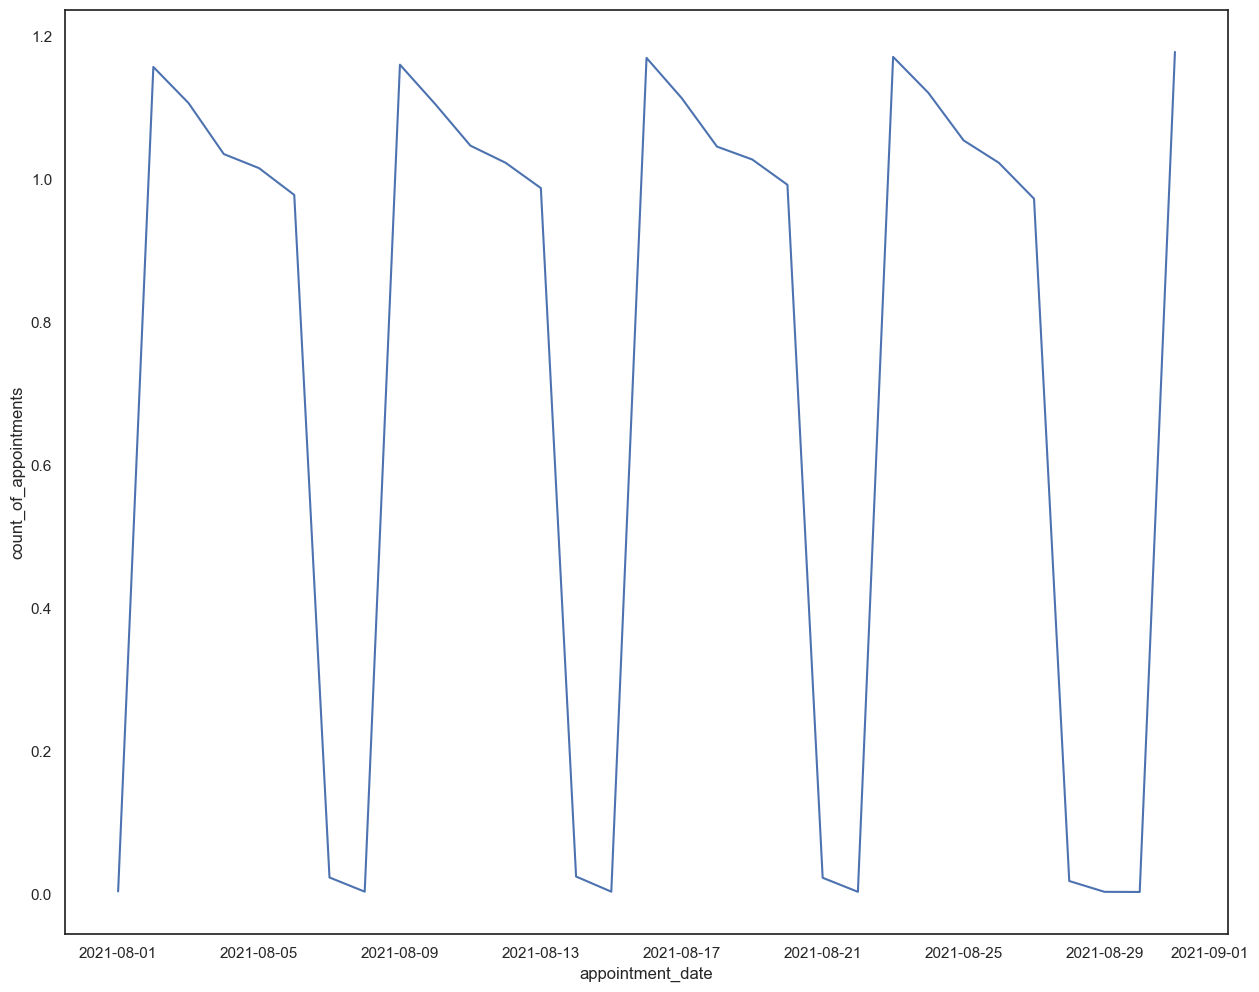

In [377]:
sns.lineplot(data=summer, x='appointment_date', y=summer['count_of_appointments']/1000000, estimator='sum', ci=None)

## Key Finding 
Upon first analysis of Summer, the NC database cannot be analysed accurately by season because the date range is too small. It does not cover all summmer months.

<Figure size 1600x1000 with 0 Axes>

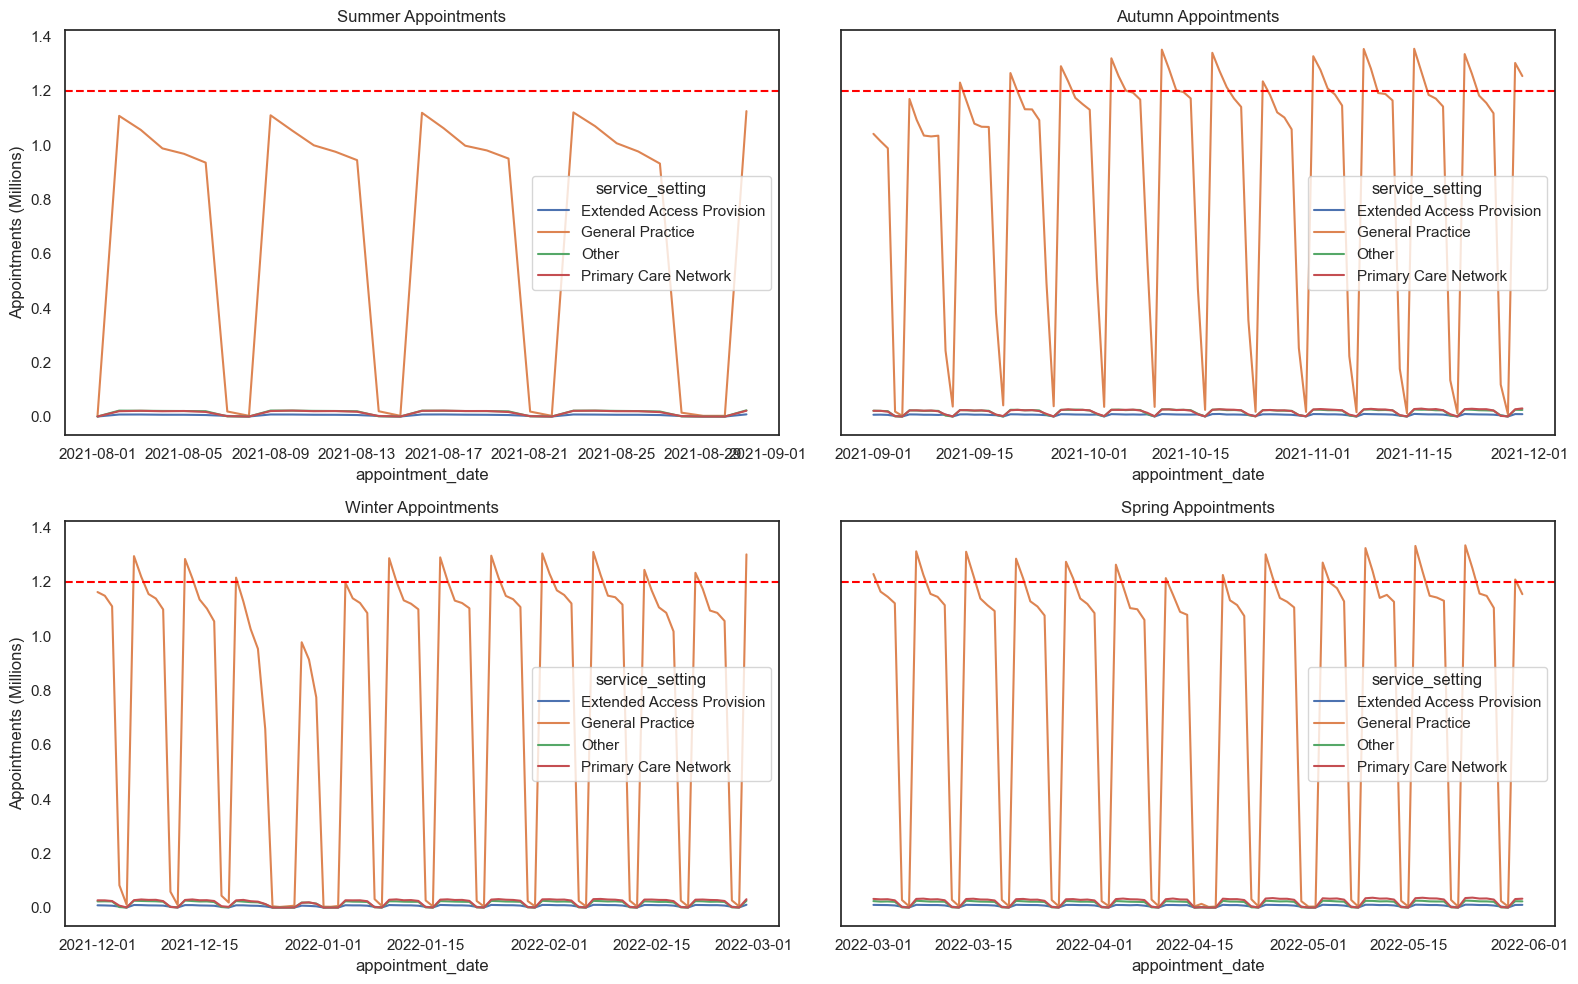

In [378]:
# Graphing Seasonal Data on one plot for ease of comparison  

# creating a figure for the plots and making their axes the same 
plt.figure(figsize=(16, 10))
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)

#setting NHS daily appts average as benchmark
benchmark = 1.2

# Using the NHS benchmark of 1.2 million appts/ day
benchmark = 1.2

# Summer
plt.subplot(2, 2, 1)
sns.lineplot(data=summer, x='appointment_date', y=summer['count_of_appointments']/ 1000000, hue='service_setting', ci=None)
plt.axhline(y=benchmark, color='red', linestyle='--',label=f'Daily Appt Benchmark ({benchmark}%)')
plt.title('Summer Appointments')
plt.ylabel('Appointments (Millions)')

# Autumn
plt.subplot(2, 2, 2)
sns.lineplot(data=autumn, x='appointment_date', y=autumn['count_of_appointments'] / 1000000, hue='service_setting', ci=None)
plt.axhline(y=benchmark, color='red', linestyle='--')
plt.title('Autumn Appointments')
plt.ylabel('Appointments (Millions)')

# Winter
plt.subplot(2, 2, 3)
sns.lineplot(data=winter, x='appointment_date', y=winter['count_of_appointments'] / 1000000, hue='service_setting', ci=None)
plt.axhline(y=benchmark, color='red', linestyle='--')
plt.title('Winter Appointments')
plt.ylabel('Appointments (Millions)')

# Spring
plt.subplot(2, 2, 4) 
sns.lineplot(data=spring, x='appointment_date', y=spring['count_of_appointments'] / 1000000, hue='service_setting', ci=None)
plt.axhline(y=benchmark, color='red', linestyle='--')
plt.title('Spring Appointments')
plt.ylabel('Appointments (Millions)')

# View all together
plt.tight_layout() 
plt.savefig('seasonal_report.png')
plt.show() 

In [379]:
# Confirming NC date range 
print(nc_ss_day['appointment_month'].unique())

['2021-08' '2021-09' '2021-10' '2021-11' '2021-12' '2022-01' '2022-02'
 '2022-03' '2022-04' '2022-05' '2022-06']


## Trends 
Summer: Cannot accurately analyse based on incomplete date info
Autumn: GP appts hover at 1.3-1.4 mil (highest month, perhaps start of flu season?)
Winter: GP appts hover at 1.2-1.3 mil.
Spring: GP appts hover at 1.2 - 1.3 mil. 


## Service Setting Seasonal Analysis 

In [380]:
# Determining benchmark count of appts per service setting on weekdays 
daily_totals = nc_ss_day 

# Creating totals per day
daily_totals['appointment_date'] = pd.to_datetime(daily_totals['appointment_date'])

# Sorting dates into weekkly number categories
daily_totals['day_num'] = daily_totals['appointment_date'].dt.dayofweek

# filtering for only weekday values (0-4) 
weekday_totals = daily_totals[daily_totals['day_num'] < 5]

# Calculating Averages 
weekday_averages = weekday_totals.groupby('service_setting')['count_of_appointments'].mean()

# viewing averages and applying correct numeric formatting 
print(weekday_averages.apply(lambda x: f"{x:,.0f}"))

service_setting
Extended Access Provision        8,256
General Practice             1,110,834
Other                           22,101
Primary Care Network            26,563
Name: count_of_appointments, dtype: object


In [381]:
# Checking the weekly average for all total appointments
weekday_averages_df = weekday_averages.to_frame()
print(weekday_averages_df.columns)
weekday_averages_df['count_of_appointments'].sum()

# Printing the average # of appointments / day 
print(f"The NHS averages {weekday_averages_df['count_of_appointments'].sum():,.0f} appointments a day")

Index(['count_of_appointments'], dtype='object')
The NHS averages 1,167,754 appointments a day


<Figure size 1600x1000 with 0 Axes>

<Figure size 1600x1000 with 0 Axes>

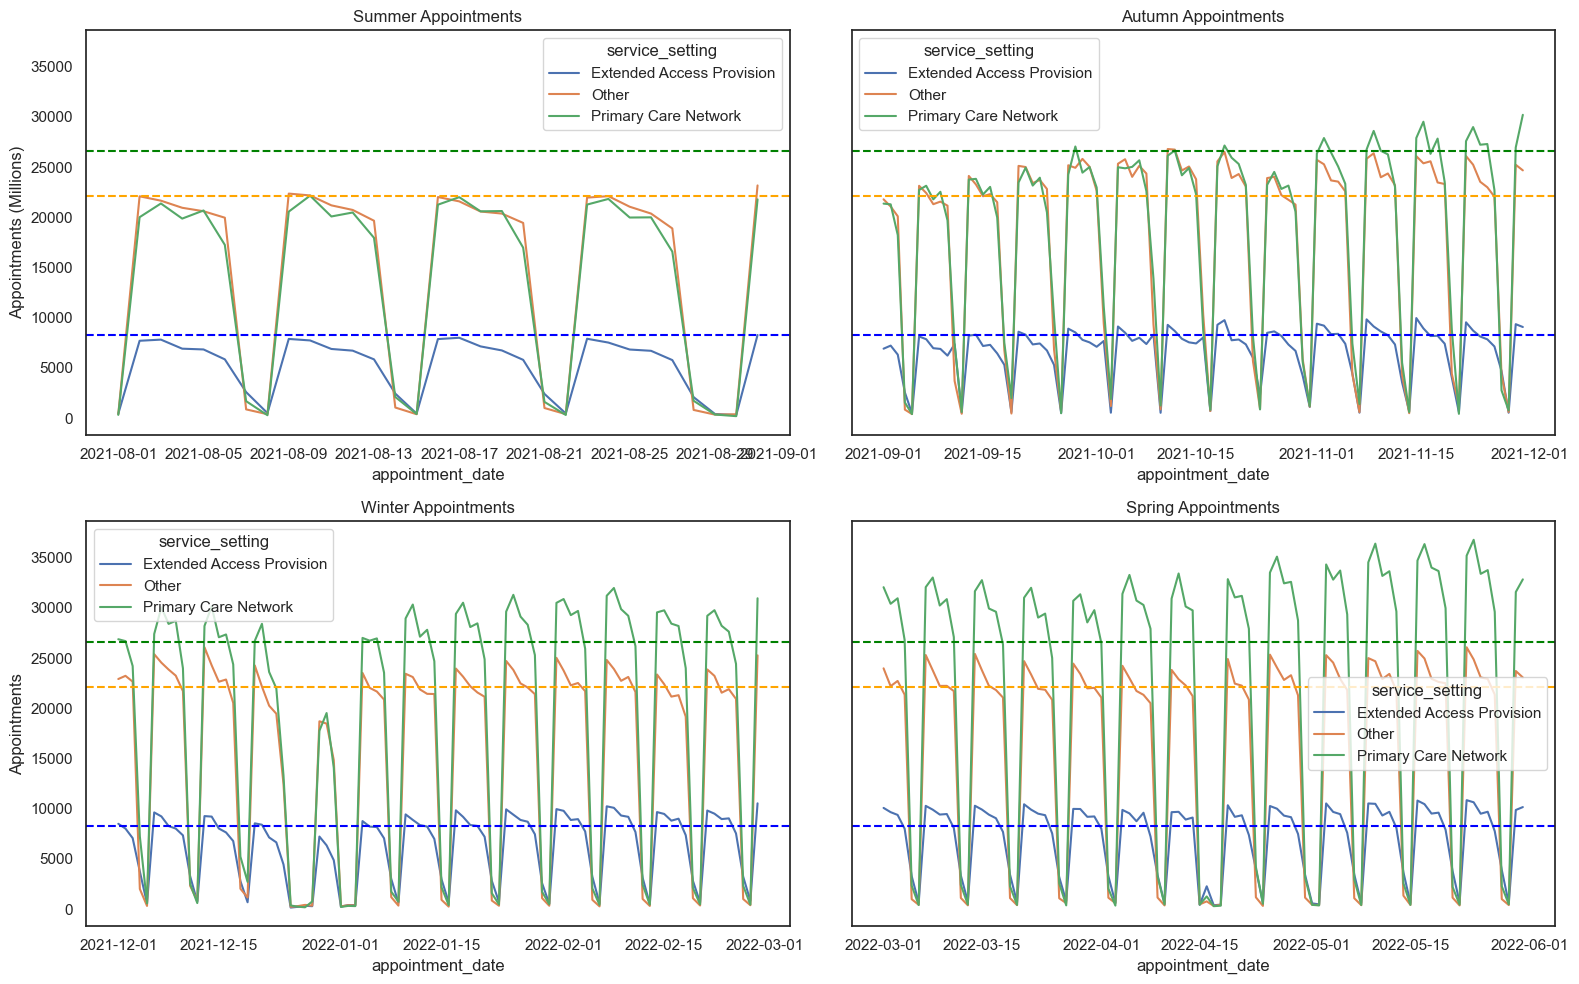

In [382]:
# Same analysis but focusing on all other service settings. 

# creating our benchmarks 
EAP_benchmark = 8256
other_benchmark = 22101
PCN_benchmark = 26563

# creating new datasets excluding GP appointments
filtered_summer = summer[summer['service_setting'] != 'General Practice']
filtered_autumn = autumn[autumn['service_setting'] != 'General Practice']
filtered_winter = winter[winter['service_setting'] != 'General Practice']
filtered_spring = spring[spring['service_setting'] != 'General Practice']


# Create the large container for all 4 graphs
plt.figure(figsize=(16, 10))
plt.figure(figsize=(16, 10))
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)

# Summer
plt.subplot(2, 2, 1)
sns.lineplot(data=filtered_summer, x='appointment_date', y=summer['count_of_appointments'], hue='service_setting', ci=None)
plt.axhline(y=EAP_benchmark, color='blue', linestyle='--')
plt.axhline(y=other_benchmark, color='orange', linestyle='--')
plt.axhline(y=PCN_benchmark, color='green', linestyle='--')
plt.title('Summer Appointments')
plt.ylabel('Appointments (Millions)')

# Autumn
plt.subplot(2, 2, 2)
sns.lineplot(data=filtered_autumn, x='appointment_date', y=autumn['count_of_appointments'], hue='service_setting', ci=None)
plt.axhline(y=EAP_benchmark, color='blue', linestyle='--')
plt.axhline(y=other_benchmark, color='orange', linestyle='--')
plt.axhline(y=PCN_benchmark, color='green', linestyle='--')
plt.title('Autumn Appointments')
plt.ylabel('Appointments')

# Winter
plt.subplot(2, 2, 3)
sns.lineplot(data=filtered_winter, x='appointment_date', y=winter['count_of_appointments'], hue='service_setting', ci=None)
plt.axhline(y=EAP_benchmark, color='blue', linestyle='--')
plt.axhline(y=other_benchmark, color='orange', linestyle='--')
plt.axhline(y=PCN_benchmark, color='green', linestyle='--')
plt.title('Winter Appointments')
plt.ylabel('Appointments')

# Spring
plt.subplot(2, 2, 4) 
sns.lineplot(data=filtered_spring, x='appointment_date', y=spring['count_of_appointments'], hue='service_setting', ci=None)
plt.axhline(y=EAP_benchmark, color='blue', linestyle='--')
plt.axhline(y=other_benchmark, color='orange', linestyle='--')
plt.axhline(y=PCN_benchmark, color='green', linestyle='--')
plt.title('Spring Appointments')
plt.ylabel('Appointments')

# View all together
plt.tight_layout() 
plt.savefig('seasonal_report2.png')
plt.show() 

## Findings
These findings are incomplete due to the absence of correct dates in the NC DataFrame, we can view trends but it may not be representative of the dataset as a whole. 

Summer: Cannot accurately analyse summer due to incomplete time set. 

Autumn: EAP seems to be at average / slightly above. Other is above average. PCN is roughly average

Winter: ALL SS above average 

Spring: All SS above average

## Seasonal Analysis with Regional Appointment Data (AR)
This next section will focus on seasonal trends based on the AR dataframe. it will investigate count of appointments by season, wait times per season and attendance rates per season. 

As the AR data frame covers the correct dates(June 2021 - May 2022), we are able to analyse seasonally. 

In [383]:
# First we are analysing Total GP and Other Practitioner Appts accross the season 

# Creating start and end dates to find seasonal averages 
start_date_seasonal = '2021-06'
end_date_seasonal = '2022-05'
seasonal_df = ar_clean[(ar_clean['appointment_month'] >= start_date_seasonal) & 
                       (ar_clean['appointment_month'] <= end_date_seasonal)].copy()

# Next we are calculating the average number of Appts per month per HCP type to use as a benchmark to compare capacity

# Calculating total apppointments accross timeframe
monthly_totals_seasonal = seasonal_df.groupby([
    'appointment_month','hcp_type'])['count_of_appointments'].sum().reset_index()

# Finding Averages
benchmarks_seasonal = monthly_totals_seasonal.groupby('hcp_type')['count_of_appointments'].mean()

# View Output 
benchmarks_seasonal.apply(lambda x: f"{x:,.0f}")

hcp_type
GP                      13,572,177
Other Practice staff    12,443,940
Name: count_of_appointments, dtype: object

<Figure size 1600x1000 with 0 Axes>

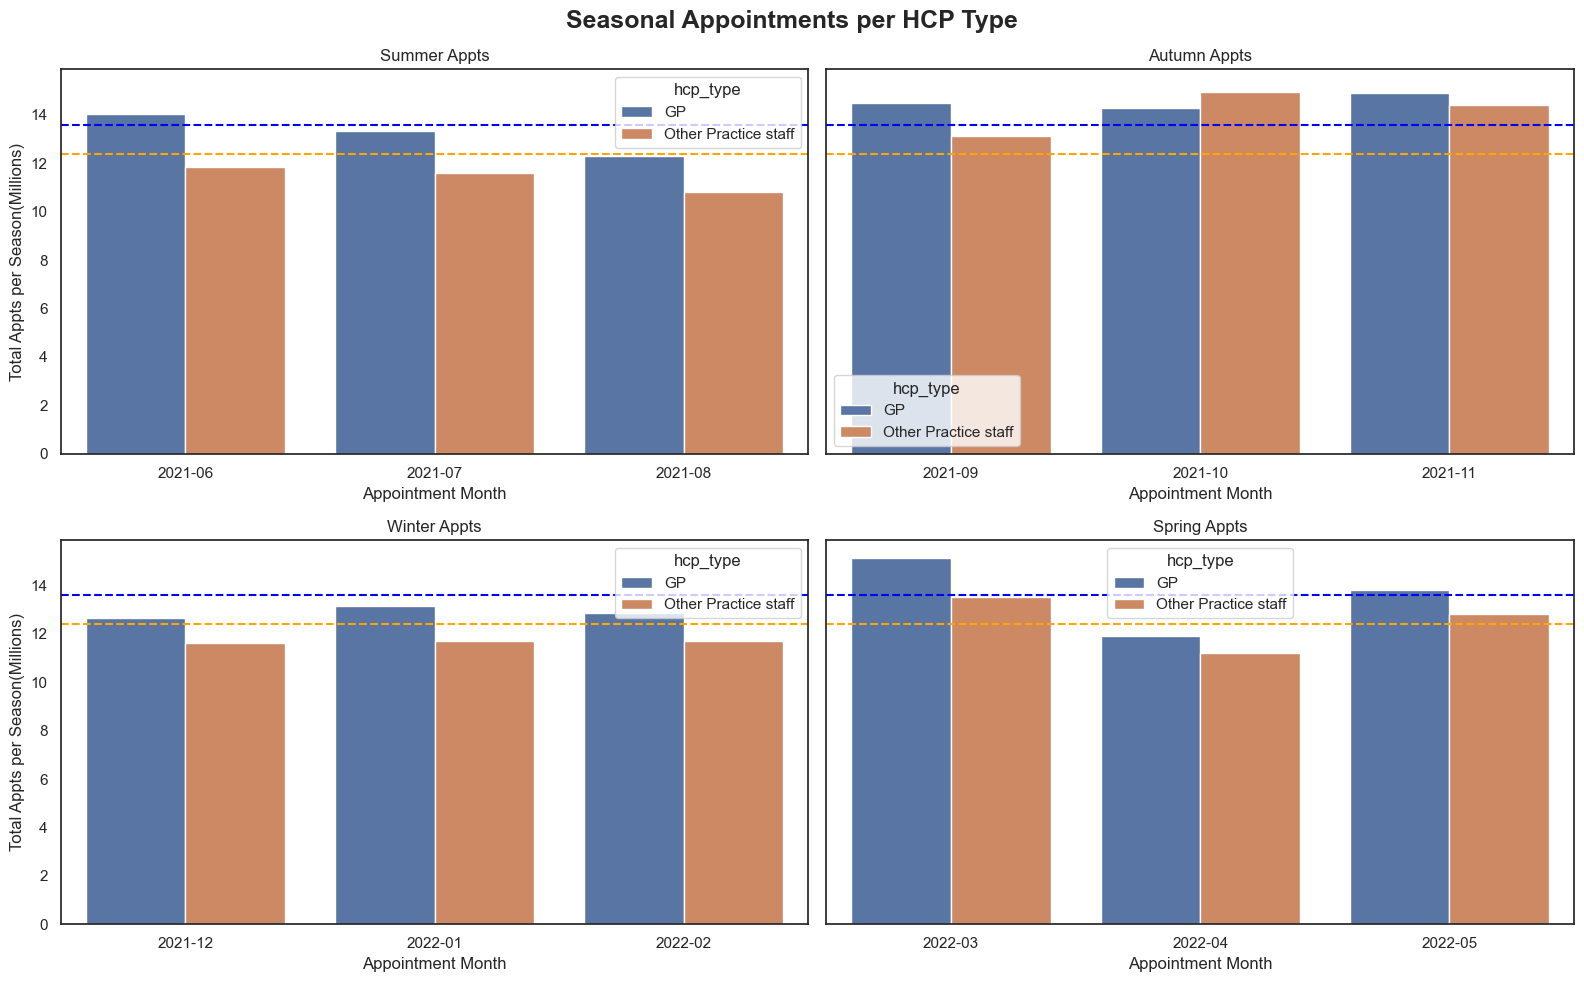

In [384]:
# Next we are plotting the data per season on one Subplot 

# Setting plot size and unifying axes 
plt.figure(figsize=(16, 10))
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
fig.suptitle('Seasonal Appointments per HCP Type', fontsize=18, fontweight='bold')

# Setting our benchmark values divided by 1,000,000 for scale 
benchmark_gp_appts = 13.6
benchmark_other_apps = 12.4

# Summer 
plt.subplot(2, 2, 1)
sns.barplot(data=summer_wait, x='appointment_month', y=summer_wait['count_of_appointments'] / 1000000, hue='hcp_type', ci=None)
plt.title("Summer Appts")
plt.xlabel("Appointment Month")
plt.ylabel("Total Appts per Season(Millions)")
plt.axhline(y=benchmark_gp_appts, color='blue', linestyle='--')
plt.axhline(y=benchmark_other_apps, color='orange', linestyle='--')

# Autumn
plt.subplot(2,2,2)
sns.barplot(data=autumn_wait, x='appointment_month', y=autumn_wait['count_of_appointments'] / 1000000, hue='hcp_type', ci=None)
plt.title("Autumn Appts")
plt.xlabel("Appointment Month")
plt.ylabel("Total Appts per Season(Millions)")
plt.axhline(y=benchmark_gp_appts, color='blue', linestyle='--')
plt.axhline(y=benchmark_other_apps, color='orange', linestyle='--')

# Winter
plt.subplot(2,2,3)
sns.barplot(data=winter_wait, x='appointment_month', y=winter_wait['count_of_appointments'] / 1000000, hue='hcp_type', ci=None)
plt.title("Winter Appts")
plt.xlabel("Appointment Month")
plt.ylabel("Total Appts per Season(Millions)")
plt.axhline(y=benchmark_gp_appts, color='blue', linestyle='--')
plt.axhline(y=benchmark_other_apps, color='orange', linestyle='--')

#Spring
plt.subplot(2,2,4)
sns.barplot(data=spring_wait, x='appointment_month', y=spring_wait['count_of_appointments'] / 1000000, hue='hcp_type', ci=None)
plt.title("Spring Appts")
plt.xlabel("Appointment Month")
plt.ylabel("Total Appts per Season(Millions)")
plt.axhline(y=benchmark_gp_appts, color='blue', linestyle='--')
plt.axhline(y=benchmark_other_apps, color='orange', linestyle='--')

# View all together
plt.tight_layout() 
plt.savefig('seasonal_appointments_fig.png')
plt.show() 

## Key Findings

Summer: Appointments for both GP and OP are below average bar June for GPs (marginally above)

Autumn: Appointments for both GP and OP substantially above average 

Winter: Appointments for both GP and OP below average 

Spring: Appointments in the first month of spring are substantially above average, then substantially below and end closer to the average

## Seasonal Wait Time Analysis

In [385]:
# Create a new dataFrame that aggregates on month, count of appointment and our total weighted days to use for our wait 
ar_ss_day = ar_wait_times.groupby(['appointment_month', 'hcp_type']).agg({
    'count_of_appointments' : 'sum',
    'total_weighted_days' : 'sum'
}).reset_index()

# calculating average wait times based on count of appointments and weighted days 
ar_ss_day['avg_wait_days'] = ar_ss_day['total_weighted_days'] / ar_ss_day['count_of_appointments']

# View the output.
ar_ss_day.head()

,appointment_month,hcp_type,count_of_appointments,total_weighted_days,avg_wait_days
0,2020-01,GP,14168932,72628634.5,5.125907
1,2020-01,Other Practice staff,12326031,107778402.5,8.743967
2,2020-02,GP,12467976,64791457.5,5.196630
3,2020-02,Other Practice staff,11002550,96304564.5,8.752931
4,2020-03,GP,12839993,64500590.5,5.023413


In [386]:
# Creating seasonal filters
summer_wait = ar_ss_day[ar_ss_day['appointment_month'].isin(['2021-06', '2021-07', '2021-08'])]
autumn_wait = ar_ss_day[ar_ss_day['appointment_month'].isin(['2021-09', '2021-10', '2021-11'])]
winter_wait = ar_ss_day[ar_ss_day['appointment_month'].isin(['2021-12', '2022-01', '2022-02'])]
spring_wait = ar_ss_day[ar_ss_day['appointment_month'].isin(['2022-03', '2022-04', '2022-05'])]

In [387]:
# Determining benchmark values 
ar_ss_day.groupby('hcp_type')['avg_wait_days'].mean()

hcp_type
GP                      3.314093
Other Practice staff    7.412712
Name: avg_wait_days, dtype: float64

<Figure size 1600x1000 with 0 Axes>

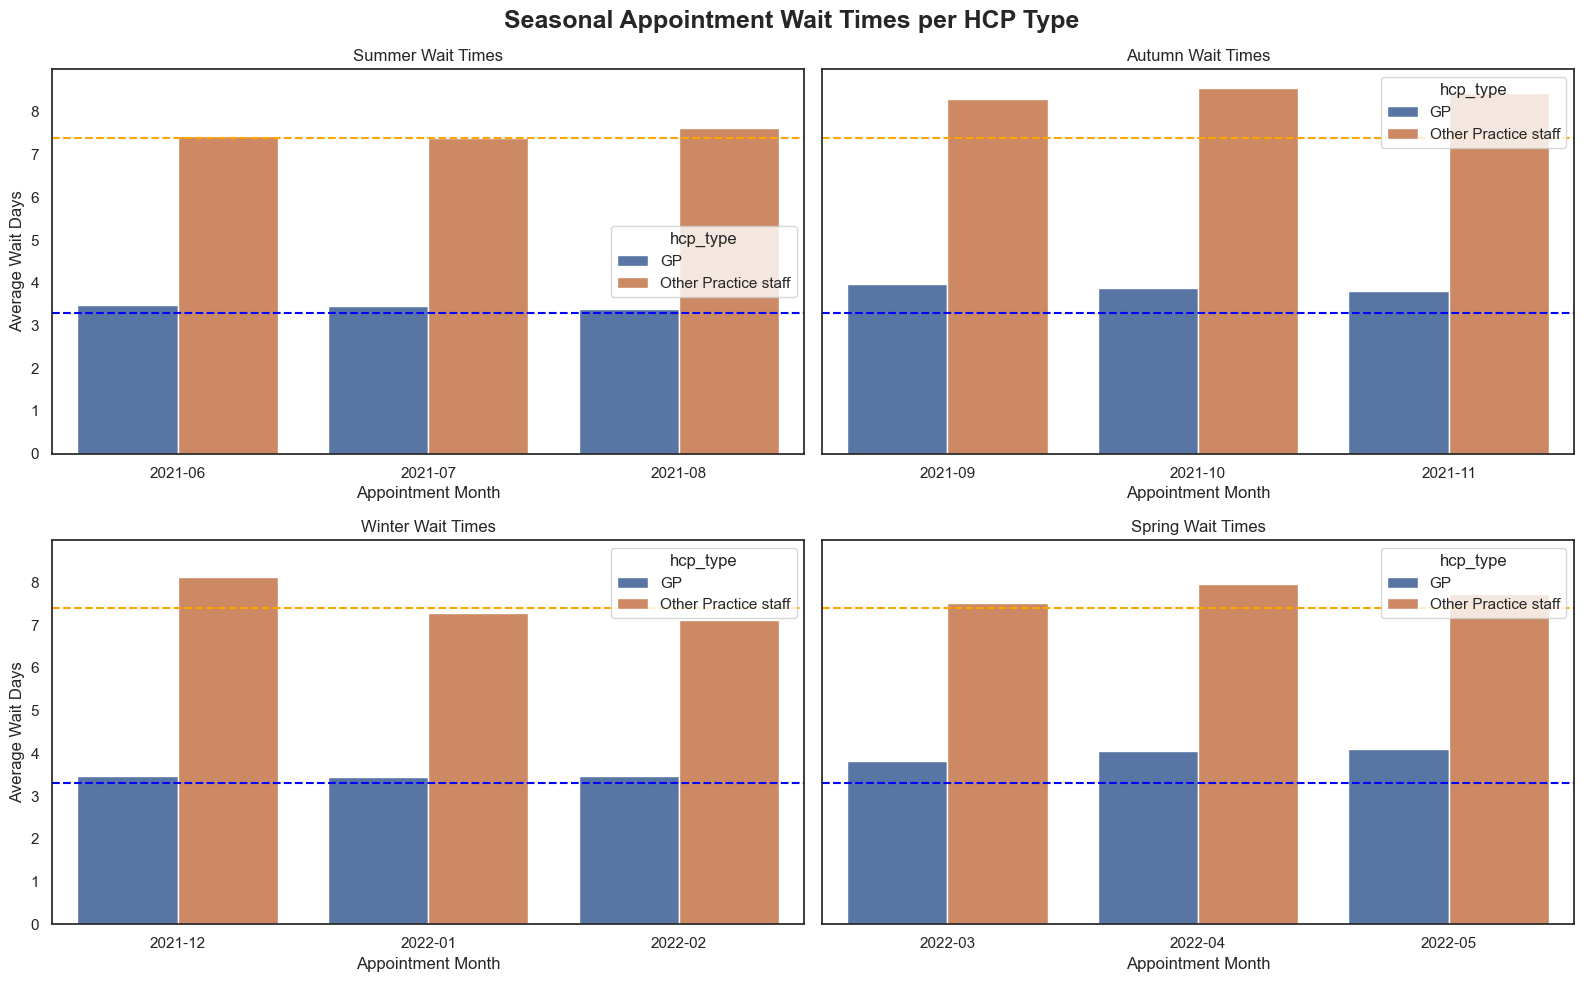

In [388]:
# Creating grouped plots

# Setting figure size and axis count
plt.figure(figsize=(16, 10))
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
fig.suptitle('Seasonal Appointment Wait Times per HCP Type', fontsize=18, fontweight='bold')

# Setting our benchmark values
benchmark_gp = 3.3
benchmark_other = 7.4

# SUmmer Plot 
plt.subplot(2, 2, 1)
sns.barplot(data=summer_wait, x='appointment_month', y='avg_wait_days', hue='hcp_type', ci=None)
plt.title("Summer Wait Times")
plt.xlabel("Appointment Month")
plt.ylabel("Average Wait Days")
plt.axhline(y=benchmark_gp, color='blue', linestyle='--')
plt.axhline(y=benchmark_other, color='orange', linestyle='--')

# Autumn Plot 
plt.subplot(2,2,2)
sns.barplot(data=autumn_wait, x='appointment_month', y='avg_wait_days', hue='hcp_type', ci=None)
plt.title("Autumn Wait Times")
plt.xlabel("Appointment Month")
plt.ylabel("Average Wait Days")
plt.axhline(y=benchmark_gp, color='blue', linestyle='--')
plt.axhline(y=benchmark_other, color='orange', linestyle='--')

# Winter Plot
plt.subplot(2,2,3)
sns.barplot(data=winter_wait, x='appointment_month', y='avg_wait_days', hue='hcp_type', ci=None)
plt.title("Winter Wait Times")
plt.xlabel("Appointment Month")
plt.ylabel("Average Wait Days")
plt.axhline(y=benchmark_gp, color='blue', linestyle='--')
plt.axhline(y=benchmark_other, color='orange', linestyle='--')

# Spring PLot 
plt.subplot(2,2,4)
sns.barplot(data=spring_wait, x='appointment_month', y='avg_wait_days', hue='hcp_type', ci=None)
plt.title("Spring Wait Times")
plt.xlabel("Appointment Month")
plt.ylabel("Average Wait Days")
plt.axhline(y=benchmark_gp, color='blue', linestyle='--')
plt.axhline(y=benchmark_other, color='orange', linestyle='--')

# View all together
plt.tight_layout() 
plt.savefig('seasonal_wait_times.png')
plt.show() 

## Key FIndings
- We can see that Other staff wait times peak in autumn and then again in april.
- GPs exceed their average wait time each month in Autumn and spring.
- As the number of appointments also peaks in Autumn, there may be a link between staff capacity and wait time

## Seasonal Resource Analysis - Staff to Patient Ratios (External Data)
This next section uses NHS provided data on staff and patient numbers from June 2021 - May 2022. 

in the interest of time, data was manually inputted from the site into separate Dataframes. 

Figures used: 
- Appts: The 'Patients Registered at GP Practices in England' figure was extracted from the NHS website
- GPs: The 'FTE ALL GPs' figure was extracted from the NHS website.
- Other Practitioners: The 'FTE Nurses' was added to the 'FTE Direct Patient Care Staff' figure from the NHS website.

Whilst it is unclear if these figures represent the same staff recorded in our provided data, we can use the NHS data to analyse general staffing and patient trends

Websites Used:
- https://digital.nhs.uk/data-and-information/publications/statistical/patients-registered-at-a-gp-practice
- https://digital.nhs.uk/data-and-information/publications/statistical/nhs-workforce-statistics/june-2021
- https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-may-2022

In [389]:
# creating a dataset for each season based on information from the NHS website 
Data_Summer = {
    'appointment_month': ['2021-06', '2021-07', '2021-08'],
    'Patients' : [60860759, 60970002, 61032314],
    'GP' : [34726, 34354, 36233], 
    'Other Practitioner' : [30378, 30192, 30316]
}

# Converting to DataFrame
nhs_summer = pd.DataFrame(Data_Summer)

# Creating Autumn dataset
Data_autumn = {
    'appointment_month': ['2021-09', '2021-10', '2021-11'],
    'Patients' : [61086074, 61194033, 61300225],
    'GP' : [36275, 36118, 35991], 
    'Other Practitioner' : [30536, 30709, 30853]
}
# Converting to DataFrame
nhs_autumn = pd.DataFrame(Data_autumn)

# Creating Winter dataset
Data_winter = {
    'appointment_month': ['2021-12', '2022-01', '2022-02'],
    'Patients' : [61395839, 61469262, 61526961],
    'GP' : [36191, 36009, 36141], 
    'Other Practitioner' : [31436, 31494, 31651]
}
# Converting to DataFrame
nhs_winter = pd.DataFrame(Data_winter)

# Creating Spring dataset
Data_spring = {
    'appointment_month': ['2022-03', '2022-04', '2022-05'],
    'Patients' : [61573603, 61625745, 61654788],
    'GP' : [35988, 35855, 35626], 
    'Other Practitioner' : [31756, 31983, 32024]
}
# Converting to DataFrame
nhs_spring = pd.DataFrame(Data_spring)

In [390]:
all_seasons = pd.concat([nhs_summer, nhs_autumn, nhs_winter, nhs_spring])

# reshaping data
all_seasons_df = all_seasons.melt(
    id_vars=['appointment_month', 'Patients'], 
    value_vars=['GP', 'Other Practitioner'],
    var_name='hcp_type', 
    value_name='Staff'
)

# sort data
all_seasons_df = all_seasons_df.sort_values(['appointment_month', 'hcp_type']).reset_index(drop=True)

# View DataFrame
all_seasons_df

,appointment_month,Patients,hcp_type,Staff
0,2021-06,60860759,GP,34726
1,2021-06,60860759,Other Practitioner,30378
2,2021-07,60970002,GP,34354
3,2021-07,60970002,Other Practitioner,30192
4,2021-08,61032314,GP,36233
5,2021-08,61032314,Other Practitioner,30316
6,2021-09,61086074,GP,36275
7,2021-09,61086074,Other Practitioner,30536
8,2021-10,61194033,GP,36118
9,2021-10,61194033,Other Practitioner,30709


In [391]:
all_seasons_df['patients_per_staff'] = all_seasons_df['Patients'] / all_seasons_df['Staff']

# Get the average workload
workload_avg = all_seasons_df.groupby('hcp_type')['patients_per_staff'].mean()
all_seasons_df

,appointment_month,Patients,hcp_type,Staff,patients_per_staff
0,2021-06,60860759,GP,34726,1752.599176
1,2021-06,60860759,Other Practitioner,30378,2003.448515
2,2021-07,60970002,GP,34354,1774.757001
3,2021-07,60970002,Other Practitioner,30192,2019.409181
4,2021-08,61032314,GP,36233,1684.439986
5,2021-08,61032314,Other Practitioner,30316,2013.204710
6,2021-09,61086074,GP,36275,1683.971716
7,2021-09,61086074,Other Practitioner,30536,2000.460899
8,2021-10,61194033,GP,36118,1694.280774
9,2021-10,61194033,Other Practitioner,30709,1992.706796


In [392]:
# set seasonal timeframes 
summer_analysis_set = all_seasons_df[all_seasons_df['Month'].isin(['2021-06', '2021-07', '2021-08'])]
autumn_analysis_set = all_seasons_df[all_seasons_df['Month'].isin(['2021-09', '2021-10', '2021-11'])]
winter_analysis_set = all_seasons_df[all_seasons_df['Month'].isin(['2021-12', '2022-01', '2022-02'])]
spring_analysis_set = all_seasons_df[all_seasons_df['Month'].isin(['2022-03', '2022-04', '2022-05'])]

KeyError: 'Month'

In [ ]:
# calculate average staff levels to use for benchmark
average_staff = all_seasons_df.groupby('hcp_type')['patients_per_staff'].mean()
print(f"The average Patients per staff are: {average_staff}")

In [ ]:
# Plotting the Staff to patient split per season on a combind subplot 

# set figure size and axes
plt.figure(figsize=(16, 10))
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
fig.suptitle('Seasonal Staff to Patient Levels per HCP Type', fontsize=18, fontweight='bold')

# set our benchmarks 
gp_avg_bench = 1713
other_avg_bench = 1971

# divide into seasons 
plt.subplot(2,2,1)
sns.barplot(data=summer_analysis_set, x='Month', y='patients_per_staff', hue='hcp_type', ci=None)
plt.title("Summer Staff Levels")
plt.xlabel("Appointment Month")
plt.ylabel("Patients per Staff")
plt.axhline(y=gp_avg_bench, color='blue', linestyle='--')
plt.axhline(y=other_avg_bench, color='orange', linestyle='--')

# Autumn
plt.subplot(2,2,2)
sns.barplot(data=autumn_analysis_set, x='Month', y='patients_per_staff', hue='hcp_type', ci=None)
plt.title("Autumn Staff Levels")
plt.xlabel("Appointment Month")
plt.ylabel("Patients per Staff")
plt.axhline(y=gp_avg_bench, color='blue', linestyle='--')
plt.axhline(y=other_avg_bench, color='orange', linestyle='--')

# Winter
plt.subplot(2,2,3)
sns.barplot(data=winter_analysis_set, x='Month', y='patients_per_staff', hue='hcp_type', ci=None)
plt.title("Winter Staff Levels")
plt.xlabel("Appointment Month")
plt.ylabel("Patients per Staff")
plt.axhline(y=gp_avg_bench, color='blue', linestyle='--')
plt.axhline(y=other_avg_bench, color='orange', linestyle='--')

# Spring
plt.subplot(2,2,4)
sns.barplot(data=spring_analysis_set, x='Month', y='patients_per_staff', hue='hcp_type', ci=None)
plt.title("Spring Staff Levels")
plt.xlabel("Appointment Month")
plt.ylabel("Patients per Staff")
plt.axhline(y=gp_avg_bench, color='blue', linestyle='--')
plt.axhline(y=other_avg_bench, color='orange', linestyle='--')

# Format and save 
plt.tight_layout() 
plt.savefig('Seasonal_Staff_to_patient_levels.png')
plt.show() 

## Key Findings
We previously determined that autumn and spring are our busiest months in terms of volume of appointments. based on these graphs, the staff to patient ratio falls under the benchmark for GPs in autumn and winter and for Other practitioners, they fall under the benchmark in winter and spring. Both are over the benchmark for summer which is the least busy month. This may imply a disconnect between demand and supply of NHS staff, thus a potential area of improvement in terms of resource utilisation. These changes are very small, but the difference is worth noting. This is not a very accurate analysis becaused its based off of number of patients registered not how many had appointments. It is worth connection with actual appointment info for further investigation 


## Seasonal Appointment Attendance Rate Analysis

In [ ]:
# Analysing DNA rates based on season

#creating seasonal filters 
summer_DNA = location_stats[location_stats['appointment_month'].isin(['2021-06', '2021-07', '2021-08'])]
autumn_DNA = location_stats[location_stats['appointment_month'].isin(['2021-09', '2021-10', '2021-11'])]
winter_DNA = location_stats[location_stats['appointment_month'].isin(['2021-12', '2022-01', '2022-02'])]
spring_DNA = location_stats[location_stats['appointment_month'].isin(['2022-03', '2022-04', '2022-05'])]

In [ ]:
# Determining mean DNA rates  for healthcare types 
dna_comparison = location_stats.groupby('hcp_type')['DNA_Rate'].mean()

print(dna_comparison)

In [ ]:
# Plotting DNA rates by season 

#setting Figure size 
plt.figure(figsize=(16, 10))
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
fig.suptitle('Seasonal DNA Appointment Rates by HCP Type', fontsize=18, fontweight='bold')

# set benchmarks
benchmark_gp_dna = 42
benchmark_other_dna = 44

# Summer 
plt.subplot(2, 2, 1)
sns.barplot(data=summer_DNA, x='appointment_month', y='DNA_Rate', hue='hcp_type', ci=None)
plt.title("Summer DNA Rates")
plt.xlabel("Appointment Month")
plt.ylabel("DNA Rate(%)")
plt.axhline(y=benchmark_gp_dna, color='blue', linestyle='--')
plt.axhline(y=benchmark_other_dna, color='orange', linestyle='--')

# Autumn 
plt.subplot(2, 2, 2)
sns.barplot(data=autumn_DNA, x='appointment_month', y='DNA_Rate', hue='hcp_type', ci=None)
plt.title("Autumn DNA Rates")
plt.xlabel("Appointment Month")
plt.ylabel("DNA Rate(%)")
plt.axhline(y=benchmark_gp_dna, color='blue', linestyle='--')
plt.axhline(y=benchmark_other_dna, color='orange', linestyle='--')

# Winter
plt.subplot(2, 2, 3)
sns.barplot(data=winter_DNA, x='appointment_month', y='DNA_Rate', hue='hcp_type', ci=None)
plt.title("Winter DNA Rates")
plt.xlabel("Appointment Month")
plt.ylabel("DNA Rate(%)")
plt.axhline(y=benchmark_gp_dna, color='blue', linestyle='--')
plt.axhline(y=benchmark_other_dna, color='orange', linestyle='--')

# Spring
plt.subplot(2, 2, 4)
sns.barplot(data=spring_DNA, x='appointment_month', y='DNA_Rate', hue='hcp_type', ci=None)
plt.title("Spring DNA Rates")
plt.xlabel("Appointment Month")
plt.ylabel("DNA Rate(%)")
plt.axhline(y=benchmark_gp_dna, color='blue', linestyle='--')
plt.axhline(y=benchmark_other_dna, color='orange', linestyle='--')

In [ ]:
location_stats
dna_comparison = location_stats.groupby('hcp_type')['DNA_Rate'].mean()

print(dna_comparison)

## Key Findings 
Based on these graphs, it seems that the attendance rate seems mostly steady accross seasons except for other practitioner a have a exceed the average DNA rate in autumn and spring, specifically November and March. GPs exceed their average DNA rate in September and by a very small percentge in march and may.  

> ***Check*** that you have adequately satisfied the expectations of the current module and that you have added code comments as well as Markdown cells documenting your analytic journey and observations to satisfy the assessment criteria.

# 

## 5) Assignment activity 5

### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [ ]:
# Libraries and settings needed for analysis.
import pandas as pd
import seaborn as sns

# Set the figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display.
pd.options.display.max_colwidth = 200

In [ ]:
# Load the data set.
twitter = pd.read_csv('/Users/annievert/Desktop/LSE COURSE EVERYTHING/Course 2/ASSIGNMENT/LSE_DA201_Assignment_files- UPDATED/LSE_DA201_Assignment_files/tweets.csv')

# View the DataFrame.
twitter.head()

In [ ]:
# Explore the metadata and data set.
twiiter_retweets = twitter.sort_values('tweet_retweet_count', ascending=False)

# View DataFrame
twiiter_retweets

# Would it be useful to only look at retweeted and favourite tweet messages?
# Explain your answer.
It may be useful to focus analysis on retweets and favourited tweets as this implies popularity and thus may represent views or sentimetns held by a larger majority of people. 

In [ ]:
# Create a new DataFrame containing only the text.
pd.set_option('display.max_colwidth', None)
tweet_text = twitter[['tweet_full_text', 'tweet_retweet_count','tweet_favorite_count']].sort_values('tweet_retweet_count', ascending=False)

# View the DataFrame.
tweet_text.head(15)

In [ ]:
# Create a list including only hashtags
hashtags_list = []
for tags in twitter['tweet_entities_hashtags'].dropna():
    clean_tags = [t.strip().lower().replace('#', '') for t in tags.split(',')]
    hashtags_list.extend(clean_tags)

# Convert to Series
hashtag_series = pd.Series(hashtags_list)

# count how many times hashtag appears + convvert to Data Frame
hashtag_df = hashtag_series.value_counts().head(60).reset_index()

# Rename  columns
hashtag_df.columns = ['Hashtag', 'Frequency']

print("Top Hashtags:")
print(hashtag_df)

In [ ]:
# Investigating tweets about jobs 
job_filter = twitter['tweet_entities_hashtags'].str.contains('job', case=False, na=False)
job_tweets = twitter[job_filter].copy()

job_tweets_sorted = job_tweets.sort_values(
    by=['tweet_favorite_count', 'tweet_retweet_count'], 
    ascending=False
)
pd.set_option('display.max_colwidth', None)

results = job_tweets_sorted[['tweet_full_text', 'tweet_favorite_count', 'tweet_retweet_count']]
results.head(10)

In [ ]:
healthcare_filter = twitter['tweet_entities_hashtags'].str.contains('healthcare', case=False, na=False)
healthcare_tweets = twitter[healthcare_filter].copy()

healthcare_sorted = healthcare_tweets.sort_values(
    by=['tweet_favorite_count', 'tweet_retweet_count'], 
    ascending=False
)
pd.set_option('display.max_colwidth', None)

results_healthcare = healthcare_sorted[['tweet_full_text', 'tweet_favorite_count', 'tweet_retweet_count']]
results_healthcare.head(10)

In [ ]:
# checking for NHS mentions 
nhs_filter = twitter['tweet_full_text'].str.contains('nhs', case=False, na=False)
nhs_tweets = twitter[nhs_filter].copy()

# sort by Retweets ad Favourites 
nhs_sorted = nhs_tweets.sort_values(
    by=['tweet_favorite_count', 'tweet_retweet_count'], 
    ascending=False
)
# View full text 
pd.set_option('display.max_colwidth', None)

# Sort columns
results_nhs = nhs_sorted[['tweet_full_text', 'tweet_favorite_count', 'tweet_retweet_count']]

# view data 
results_nhs.head(10)

In [ ]:
# Checking for UK specific mentions 
na_keywords_uk = 'uk |UK |england|England|English'
nhs_filter_uk = twitter['tweet_full_text'].str.contains(na_keywords_uk, case=False, na=False)
nhs_tweets_uk = twitter[nhs_filter_uk].copy()

# sort by Retweets ad Favourites 
nhs_sorted_uk = nhs_tweets_uk.sort_values(
    by=['tweet_favorite_count', 'tweet_retweet_count'], 
    ascending=False
)
# View full text 
pd.set_option('display.max_colwidth', None)

# Sort columns
results_nhs_uk = nhs_sorted_uk[['tweet_full_text', 'tweet_favorite_count', 'tweet_retweet_count']]

# view data 
results_nhs_uk

In [ ]:
# checking for NHS mentions 
na_keywords = 'usa|america|american|canada|canadian'
nhs_filter_us = twitter['tweet_full_text'].str.contains(na_keywords, case=False, na=False)
nhs_tweets_us = twitter[nhs_filter_us].copy()

# sort by Retweets ad Favourites 
nhs_sorted_us = nhs_tweets_us.sort_values(
    by=['tweet_favorite_count', 'tweet_retweet_count'], 
    ascending=False
)
# View full text 
pd.set_option('display.max_colwidth', None)

# Sort columns
results_nhs_us = nhs_sorted_us[['tweet_full_text', 'tweet_favorite_count', 'tweet_retweet_count']]

# view data 
results_nhs_us

26 tweets related to the US healthcare system 

## Findings 
Only 3 tweets even mention the NHS, none of which appear to be commenting on utilisation. There are also a very minimal amount of 

In [ ]:
# creating barchart to view hashtags with frequency larger than 10
sns.barplot(data=hashtag_df[hashtag_df['Frequency'] > 10], y='Hashtag', x='Frequency')
plt.title('Hashtag Frequency')

## Findings 
While the data does allude to trends in recruitment and the presence of the hashtag: '#healthcare' as a popular way of speaking about trends in the healthcare world, ultimately the quality of the data in this file is not high enough to base recommendations for resource allocation or to investgate effective utlisation. the nhs is only mentioned three times in the entire dataset and many of the tweets are centred around the US and Canada. Ultimately this dataset is not strong enough to inform any recommendations. 

 > ***Check*** that you have adequately satisfied the expectations of the current module and that you have added code comments as well as Markdown cells documenting your analytic journey and observations to satisfy the assessment criteria.

# 

## 6) Assignment activity 6
In the final module you will answer additional questions from the NHS as well as additional questions and observations you identified. Make sure to revisit previous sections that may provide useful insights to the questions posed in Module 6 where required.

### Investigate the main concerns posed by the NHS. 

In [ ]:
# Load the appointments_regional.csv file.
ar_clean
# View the DataFrame.
ar_clean

In [ ]:
# Print the min and max dates.
print(ar_clean['appointment_month'].min())
print(ar_clean['appointment_month'].max())

In [ ]:
# Filter the data set to only look at data from 2021-08 onwards.
ar_clean_date_filter = ar_clean[ar_clean['appointment_month'].between('2021-07-01', '2022-06-01')]

# Checking Filter
print(ar_clean_date_filter['appointment_month'].min())
print(ar_clean_date_filter['appointment_month'].max())

**Question 1:** Should the NHS start looking at increasing staff levels? 

In [ ]:
# Create an aggregated data set to review the different features.


# View the DataFrame.


In [ ]:
# Determine the total number of appointments per month.
# based on monthly averages for 2019 - the NHS had about 24.2 million appts a month 
ar_appts_month = ar_clean_date_filter.groupby('appointment_month')['count_of_appointments'].sum().reset_index()
ar_appts_month

# Add a new column to indicate the average utilisation of services.
ar_appts_month['utilisation'] =  ar_appts_month['count_of_appointments'] / 24200000 

# Monthly aggregate / 30 to get to a daily value.
ar_appts_month['daily_average'] = ar_appts_month['count_of_appointments'] / 30

# Converting column to integer
ar_appts_month['daily_average'] = ar_appts_month['daily_average'].astype(int)

# View the DataFrame.
ar_appts_month

In [ ]:
# Plot sum of count of monthly visits.
# Convert the appointment_month to string data type for ease of visualisation.
ar_appts_month['appointment_month'] = ar_appts_month['appointment_month'].astype(str)

# Create a lineplot with Seaborn.
sns.lineplot(data=ar_appts_month, x='appointment_month', y=ar_appts_month['count_of_appointments'] / 1000000, ci=None)
plt.xlabel('Appointment Month')
plt.ylabel('Appointments (Millions)')
plt.xticks(rotation=45)

In [ ]:
# Plot monthly capacity utilisation.
# Create a lineplot.
sns.lineplot(data=ar_appts_month, x='appointment_month', y='utilisation', ci=None)
plt.xlabel('Appointment Month')
plt.ylabel('Utilisation')
plt.xticks(rotation=45)

In [ ]:
sns.barplot(data=ar_appts_month, x='appointment_month', y='utilisation', ci=None)
plt.xlabel('Appointment Month')
plt.ylabel('Utilisation')
plt.xticks(rotation=45)
plt.axhline(y=1.0, color='red', linestyle='--', label='2019 Average Baseline')

In [ ]:
# Investigating utilisation seasonally 
# setting seasonal values
summer_utilisation = ar_appts_month[ar_appts_month['appointment_month'].isin(['2021-06', '2021-07', '2021-08'])]
autumn_utilisation = ar_appts_month[ar_appts_month['appointment_month'].isin(['2021-09', '2021-10', '2021-11'])]
winter_utilisation = ar_appts_month[ar_appts_month['appointment_month'].isin(['2021-12', '2022-01', '2022-02'])]
spring_utilisation = ar_appts_month[ar_appts_month['appointment_month'].isin(['2022-03', '2022-04', '2022-05'])]

# plotting on one axis 
#setting Figure size 
plt.figure(figsize=(16, 10))
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
fig.suptitle('Seasonal Utilisation Analysis', fontsize=18, fontweight='bold')

# set benchmarks
goal_utilisation = 1

# Summer 
plt.subplot(2, 2, 1)
sns.barplot(data=summer_utilisation, x='appointment_month', y='utilisation', ci=None)
plt.title("Summer Utilisation")
plt.xlabel("Appointment Month")
plt.ylabel("Utilisation level")
plt.axhline(y=goal_utilisation, color='red', linestyle='--')

# Autumn 
plt.subplot(2, 2, 2)
sns.barplot(data=autumn_utilisation, x='appointment_month', y='utilisation', ci=None)
plt.title("Autumn Utilisation")
plt.xlabel("Appointment Month")
plt.ylabel("Utilisation level")
plt.axhline(y=goal_utilisation, color='red', linestyle='--')

# Winter
plt.subplot(2, 2, 3)
sns.barplot(data=winter_utilisation, x='appointment_month', y='utilisation', ci=None)
plt.title("Winter Utilisation")
plt.xlabel("Appointment Month")
plt.ylabel("Utilisation level")
plt.axhline(y=goal_utilisation, color='red', linestyle='--')

# Spring
plt.subplot(2, 2, 4)
sns.barplot(data=spring_utilisation, x='appointment_month', y='utilisation', ci=None)
plt.title("Spring Utilisation")
plt.xlabel("Appointment Month")
plt.ylabel("Utilisation level")
plt.axhline(y=goal_utilisation, color='red', linestyle='--')

plt.savefig('Seasonal Utilisation Analysis.png')

## Key Finding
in Autumn the utilisation standrd is surpasses significantly, it is then surpassed in the beginning and end of sprong as well. the high spikes in Autumn is consistent with our findings on wait times and the overall number of appointments held by both GP and OPs. 

In [ ]:
# creating a color coded utilisation plot 
# setting colors 
colors = ['#E57373' if x < 1.0 else '#5D8AA8' for x in ar_appts_month['utilisation']]

# Plotting data 
sns.barplot(data=ar_appts_month, x='appointment_month', y='utilisation',palette=colors, ci=None)
plt.xticks(rotation=45)
plt.xlabel('Appointment Month')
plt.ylabel('Utilisation')
plt.axhline(y=1.0, color='red', linestyle='--', label='2019 Average Baseline')

## Key Finding
80% of the time, the NHS is operating 100% utilisation. This means that the majority of the time, the NHS is  over performing in terms of appointments served based on the 2019 baseline. If the intended limits for the NHS sit at utilisation value of 1, most of the time the nhs is surpassing this - they may be operating beyond cpacity. 

**Question 2:** How do the healthcare professional types differ over time?

In [ ]:
# Create a lineplot to answer the question.
ar_clean

# Aggregating count of apts by their total per month
total_gp_appts = ar_clean.groupby(['hcp_type', 'appointment_month']).agg({'count_of_appointments' : 'sum'})

total_gp_appts

In [ ]:
import matplotlib.pyplot as plt 

# setting figure size 
plt.figure(figsize=(12, 6))

# Creating lineplot 
hcp_lineplot = sns.lineplot(data=total_gp_appts,x='appointment_month', y='count_of_appointments',hue='hcp_type' )

# Rotating labels
plt.xticks(rotation=45)

**Question 3:** Are there significant changes in whether or not visits are attended?

In [ ]:
location_stats

**Question 4:** Are there changes in terms of appointment type and the busiest months?

In [ ]:
# Create a lineplot to answer the question.
# this is shit not sure how to visualise this 
sns.lineplot(data=nc_clean, x='appointment_month', y='count_of_appointments', hue='service_setting')

**Question 5:** Are there any trends in time between booking an appointment?

In [ ]:
# Create a lineplot to answer the question.
ar

# this is also shit and not sure how to make it better
sns.lineplot(data=ar_clean, x='appointment_month', y='count_of_appointments', hue='time_between_book_and_appointment')

**Question 6:** How does the spread of service settings compare?

In [ ]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
nc

In [ ]:
# Create a boxplot to investigate the spread of service settings.
sns.boxplot(data=nc_clean, x='service_setting', y='count_of_appointments')

In [ ]:
# Create a boxplot to investigate the service settings without GP.
nc_no_gp = nc_clean[nc_clean['service_setting'] != 'General Practice']
sns.boxplot(data=nc_no_gp, x='service_setting', y='count_of_appointments')

In [ ]:
# Investigation appointment time length 
ad['actual_duration'] = ad['actual_duration'].str.strip()

# weighting times
time_weight = {
    '1-5 Minutes' : 3,
    '6-10 Minutes' : 8,
    '11-15 Minutes' : 13,
    '16-20 Minutes' : 18,
    '21-30 Minutes' : 25.5,
    '31-60 Minutes' : 45.5
}

# applying weight mapping 
ad['appt_time_weighted'] = ad['actual_duration'].map(time_weight)

# calculating weighted column 
ad['count_weighted'] = ad['count_of_appointments'] * ad['appt_time_weighted']

# sortinhg
ad_sorted = ad.sort_values('appt_time_weighted').dropna(subset=['appt_time_weighted'])


ad_sorted['cumulative_count'] = ad_sorted['count_of_appointments'].cumsum()

# view data
ad_sorted

In [ ]:
# calculating mid point 
shmad = ad_sorted.groupby('appt_time_weighted')['count_of_appointments'].sum().reset_index()

# Sorting
shmad.sort_values('appt_time_weighted', ascending=True)

# finding total 
shmad['count_of_appointments'].sum()


In [ ]:
# determining where the midpoint is
shmad
28600865 + 33800815 

In [ ]:
print("The median appointment time is between 11-15 minutes")

### Provide a summary of your findings and recommendations based on the analysis.

> ***Check*** that you have adequately satisfied the expectations of the current module and that you have added code comments as well as Markdown cells documenting your analytic journey and observations to satisfy the assessment criteria.

## Findings
> Based on seasonal trends and high intensity utilisation periods identified through our visualisations, the following recommendations are made to address the questions posed by the NHS:
Has there been adequate staff capacity in the networks?
No. based on the increased volume of appointments, wait time and utilisation levels, we can conclude that staff may be overrun specifically in the Autumn months. As sheer appointment volume and length of appointment wait time peak in Autumn, we can infer that these factors are correlated and because of the increase in demand (scheduled appointments) the supply (GP and OP availability) does not match thus driving up wait times. We recommend hiring more staff during these months to match the increase in demand. 
What was the actual utilisation of resources? 
The utilisation analysis uncovered that the NHS is consistently operating at a high appointment saturation level where actual utilisation frequency exceeds the 2019 baseline of 24.2 million appointments per month. Our utilisation visualisation clearly shows that the NHS is operating above the utilization index of 1 in 10 out of 12 months of the year. Coinciding with our previously determined seasonal peak times, utilisation reaches up to 125% of the standard operating capacity in autumn. Because utilisation exceeds 100% so frequently, we can conclude that staff are operating at an unsustainably high rate.



## Recommendations: 
- Seasonal staffing: Implement increased seasonal staffing specifically in Autumn (September-November) to address the 25% increase in operational utilisation during this period.

- Data Collection Improvements: Future analysis would benefit from refined social media (Twitter) scraping with regionally specific filters to allow for accurate UK based sentiment analysis on patient and staffing trends.

- Communication Strategy: Develop targeted text reminders for patients with appointment wait times of over 22+ days to help minimise DNA rates and avoid wasted appointment slots.